In [8]:
from copy import deepcopy
from pathlib import Path
import json
import matplotlib.pyplot as plt
import os
import polars as pl
import seaborn as sns

plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 14
plt.rcParams["lines.markersize"] = 10

# Path setup aligned with train/recsys26 scripts (util.py -> OUTPUT_ROOT/results)
if "OUTPUT_ROOT" in os.environ:
    _output_root = Path(os.environ["OUTPUT_ROOT"])
elif Path.cwd().name == "results":
    _output_root = Path.cwd().parent
else:
    _output_root = Path.cwd()
RESULTS_ROOT = _output_root / "results"

DATASETS = ["ml-32m-filtered"]
CF_MODELS = ("ELSA",)
SAE_MODELS = ("TopKSAE",)
SPLITS = ["val", "test"]

In [12]:
result_dataframes = {d: {s: {"cf models": [], "sae models": []} for s in SPLITS} for d in DATASETS}
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Results directory not found: {dataset_dir}")

    for results_file in sorted(os.listdir(dataset_dir)):
        if not results_file.endswith(".json"):
            continue

        with open(dataset_dir / results_file, "r") as f:
            d = json.load(f)
            job_cfg = d["job_cfg"]
            for split in SPLITS:
                if split not in d["results"]:
                    continue
                results_dict = d["results"][split]
                flat_results = {"checkpoint": results_file} | deepcopy(job_cfg)

                # Flatten generic one-level metrics dictionaries.
                for m, mv in results_dict.items():
                    if isinstance(mv, dict):
                        for k, v in mv.items():
                            flat_results[" ".join([m, k])] = v
                    else:
                        flat_results[m] = mv

                # CF models now report nested metrics under @10/@20.
                # Keep backward-compatible keys used by plotting cells.
                if results_file.startswith(CF_MODELS):
                    topk_key = "@20" if "@20" in results_dict else ("@10" if "@10" in results_dict else None)
                    if topk_key is not None:
                        for metric_name in ["recall", "ndcg"]:
                            metric_payload = results_dict[topk_key].get(metric_name, {})
                            if isinstance(metric_payload, dict):
                                if "mean" in metric_payload:
                                    flat_results[f"{metric_name} mean"] = metric_payload["mean"]
                                if "se" in metric_payload:
                                    flat_results[f"{metric_name} se"] = metric_payload["se"]
                    result_dataframes[dataset][split]["cf models"].append(flat_results)
                elif results_file.startswith(SAE_MODELS):
                    flat_results["input_dim"] = int(flat_results["pretrained_model_checkpoint"].split("-")[1])
                    result_dataframes[dataset][split]["sae models"].append(flat_results)

    for split in SPLITS:
        for model_type, list_of_results in result_dataframes[dataset][split].items():
            if len(list_of_results) == 0:
                # For projects without a test split (test_user_ratio=0), reuse val tables
                # so downstream plotting cells can run without manual edits.
                if split == "test" and result_dataframes[dataset]["val"][model_type].height > 0:
                    result_dataframes[dataset][split][model_type] = result_dataframes[dataset]["val"][model_type].clone()
                else:
                    result_dataframes[dataset][split][model_type] = pl.DataFrame()
                continue

            data = {k: [l.get(k) for l in list_of_results] for k in list_of_results[0].keys()}
            result_dataframes[dataset][split][model_type] = pl.DataFrame(data)
            if model_type == "sae models":
                result_dataframes[dataset][split][model_type] = (
                    result_dataframes[dataset][split][model_type]
                    .with_columns(
                        pl.when(pl.col("reconstruction_loss") == "Cosine")
                        .then(pl.col("model_class") + " (" + pl.col("reconstruction_loss") + ")")
                        .otherwise(pl.col("model_class"))
                        .alias("model_class")
                    )
                    .with_columns((pl.col("embedding_dim") / pl.col("input_dim")).cast(pl.Int32).alias("scaling_factor"))
                    .with_columns(pl.col("pretrained_model_checkpoint").str.split("-").list.first().alias("cf_model"))
                    .with_columns((pl.col("input_dim") / 512).alias("cf_model_size"))
                )

# Results tables

In [13]:
# results for dataset=ml-32m-filtered, split=val, category="sae models"
result_dataframes[DATASETS[0]]["val"]["sae models"]

# optional: if test split exists
# result_dataframes[DATASETS[0]]["test"]["cf models"]

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,f64
"""TopKSAE-16384-1ba448a0.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",16384,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.798296,0.001705,31.99338,0.002085,1030,0.3407,0.002463,-0.027815,0.00123,0.350058,0.002564,-0.03005,0.001065,2048,8,"""ELSA""",4.0
"""TopKSAE-16384-337b98a3.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",16384,"""Cosine""",0.0003,8,250,50,1024,0.0003,0.9,0.99,42,0.698321,0.001649,8.0,0.0,1660,0.316776,0.002461,-0.057021,0.001488,0.324027,0.002517,-0.059203,0.001321,2048,8,"""ELSA""",4.0
"""TopKSAE-16384-a4f931b4.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",16384,"""Cosine""",0.0003,64,250,50,1024,0.0003,0.9,0.99,42,0.847663,0.001629,63.172775,0.038587,516,0.351676,0.002505,-0.018842,0.001122,0.361193,0.0026,-0.020628,0.000952,2048,8,"""ELSA""",4.0
"""TopKSAE-16384-ef43284e.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",16384,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.741987,0.001672,16.0,0.0,1365,0.330866,0.002471,-0.041045,0.001366,0.337404,0.00254,-0.044267,0.001191,2048,8,"""ELSA""",4.0
"""TopKSAE-2048-088b6417.json""","""ml-32m-filtered""","""ELSA-1024-66e73686.ckpt""","""sae""","""TopKSAE (Cosine)""",2048,"""Cosine""",0.0003,32,60,12,1024,0.0003,0.9,0.99,42,0.818567,0.00158,32.0,0.0,0,0.343866,0.002506,-0.019491,0.001087,0.350702,0.002589,-0.020694,0.000896,1024,2,"""ELSA""",2.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""TopKSAE-4096-86effed3.json""","""ml-32m-filtered""","""ELSA-1024-66e73686.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,32,120,20,1024,0.0003,0.9,0.99,42,0.826737,0.001612,31.999838,0.000161,28,0.343953,0.002518,-0.01893,0.001076,0.350407,0.002602,-0.019302,0.000876,1024,4,"""ELSA""",2.0
"""TopKSAE-8192-3b684923.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,8,250,50,1024,0.0003,0.9,0.99,42,0.693898,0.0017,8.0,0.0,1315,0.315107,0.00245,-0.057668,0.001473,0.320289,0.00252,-0.060611,0.001327,2048,4,"""ELSA""",4.0
"""TopKSAE-8192-713489fe.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.739093,0.001741,16.0,0.0,796,0.329837,0.002494,-0.043959,0.001371,0.336577,0.002542,-0.046653,0.001197,2048,4,"""ELSA""",4.0


# Validation results

## Sparsity vs downstream accuracy

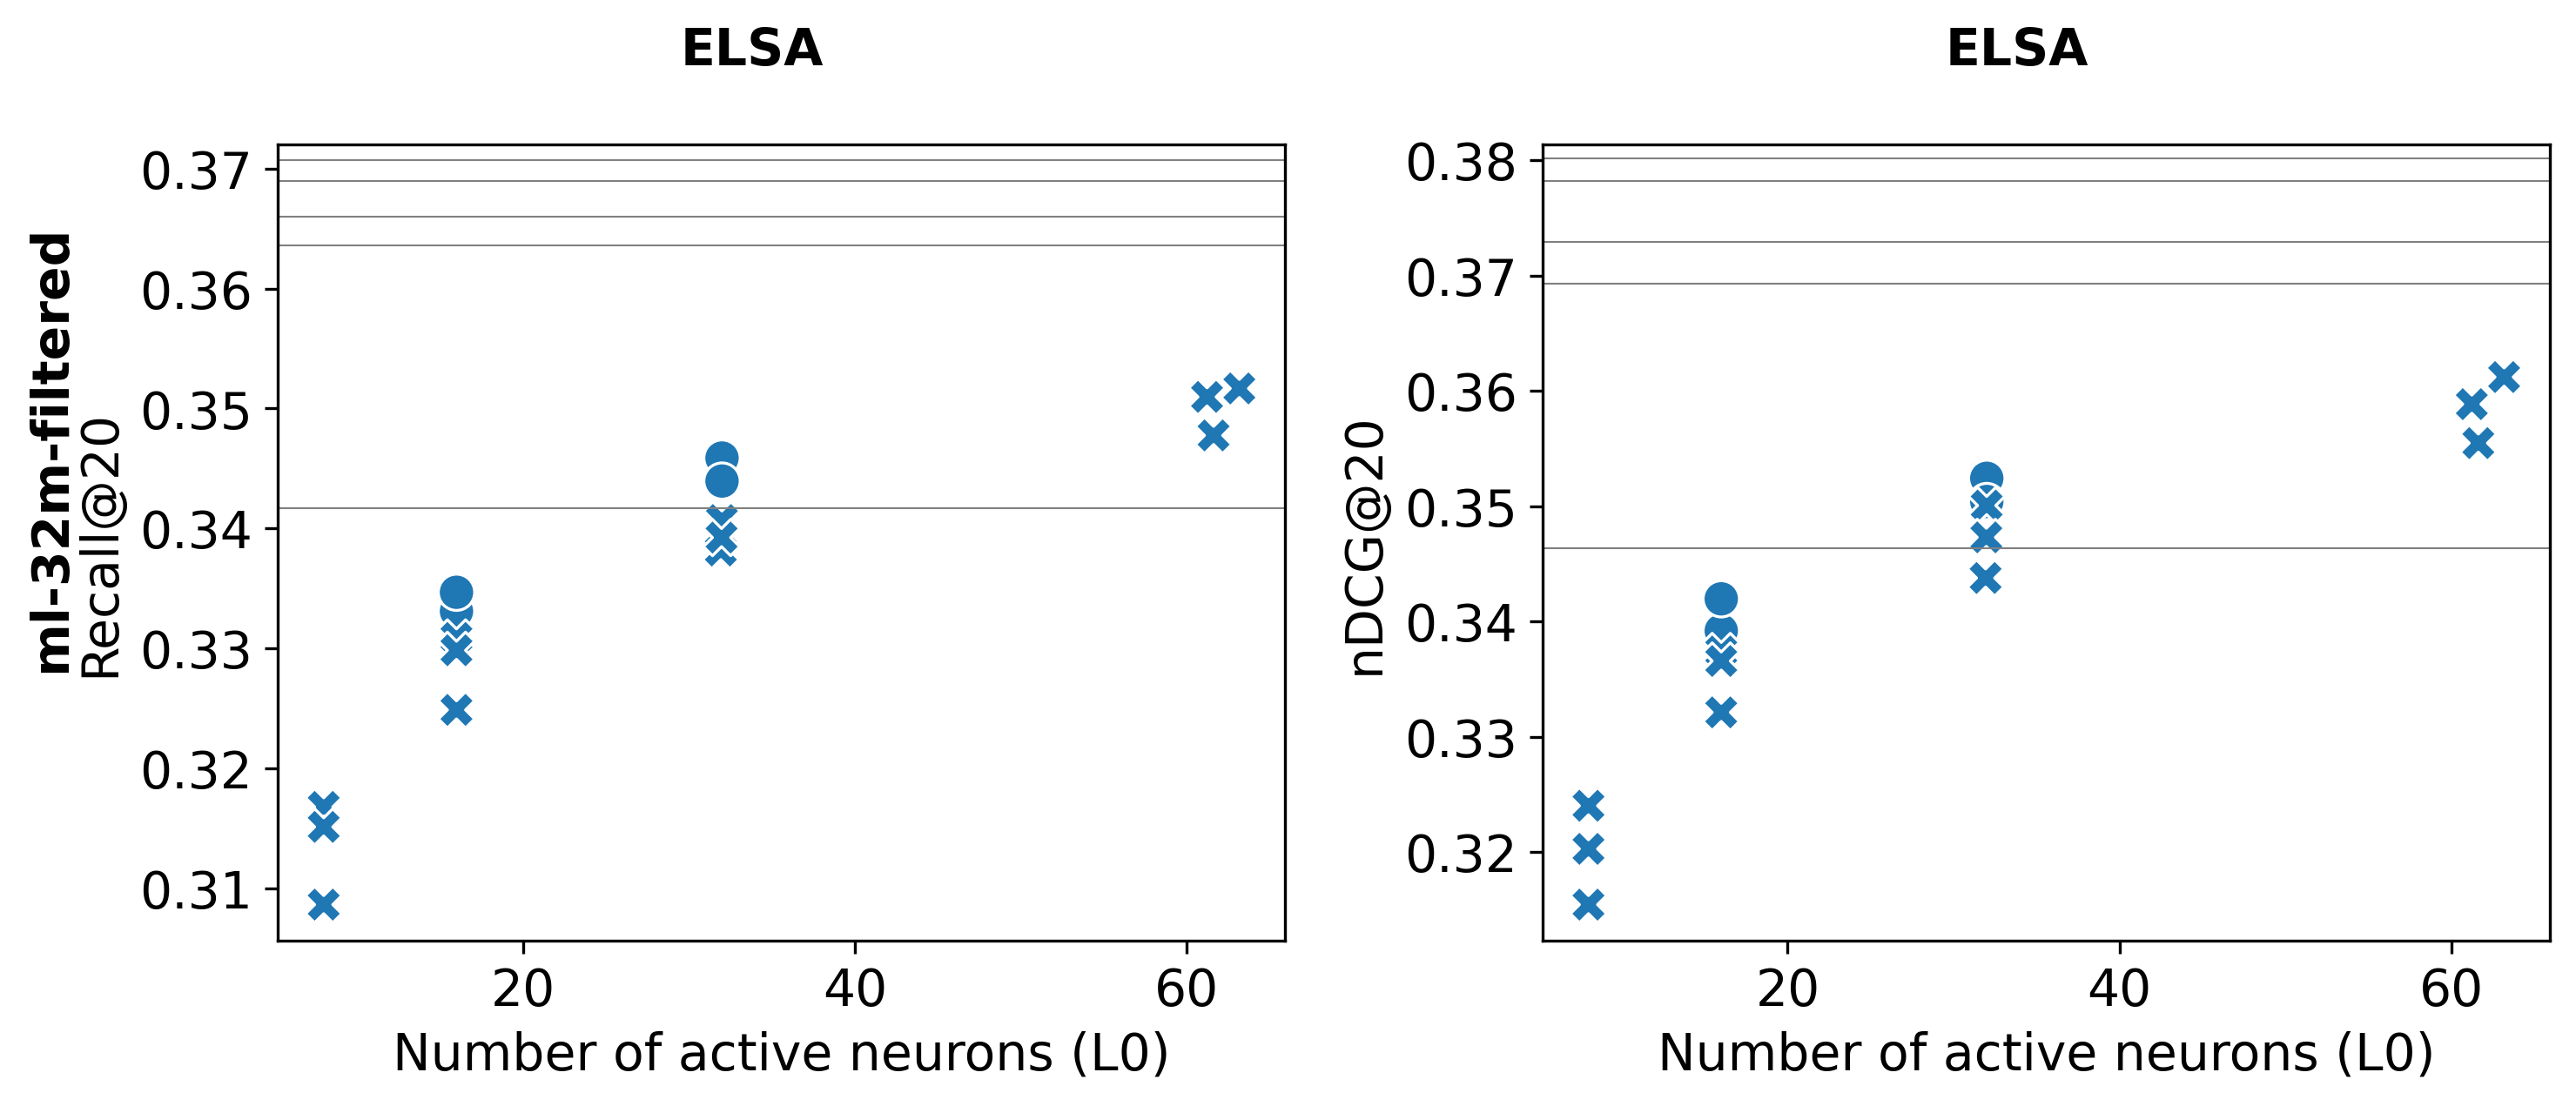

In [17]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join([exp[0], "mean"])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        for row in result_dataframes[dataset]["val"]["cf models"].filter(pl.col("model_class") == exp[1]).iter_rows(named=True):
            ax.axhline(y=row[y], color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("Recall@20" if y.startswith("recall") else "nDCG@20")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(exp[1], xy=(0.4, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold")

plt.tight_layout()

## Sparsity vs degradation in downstream accuracy

### Absolute

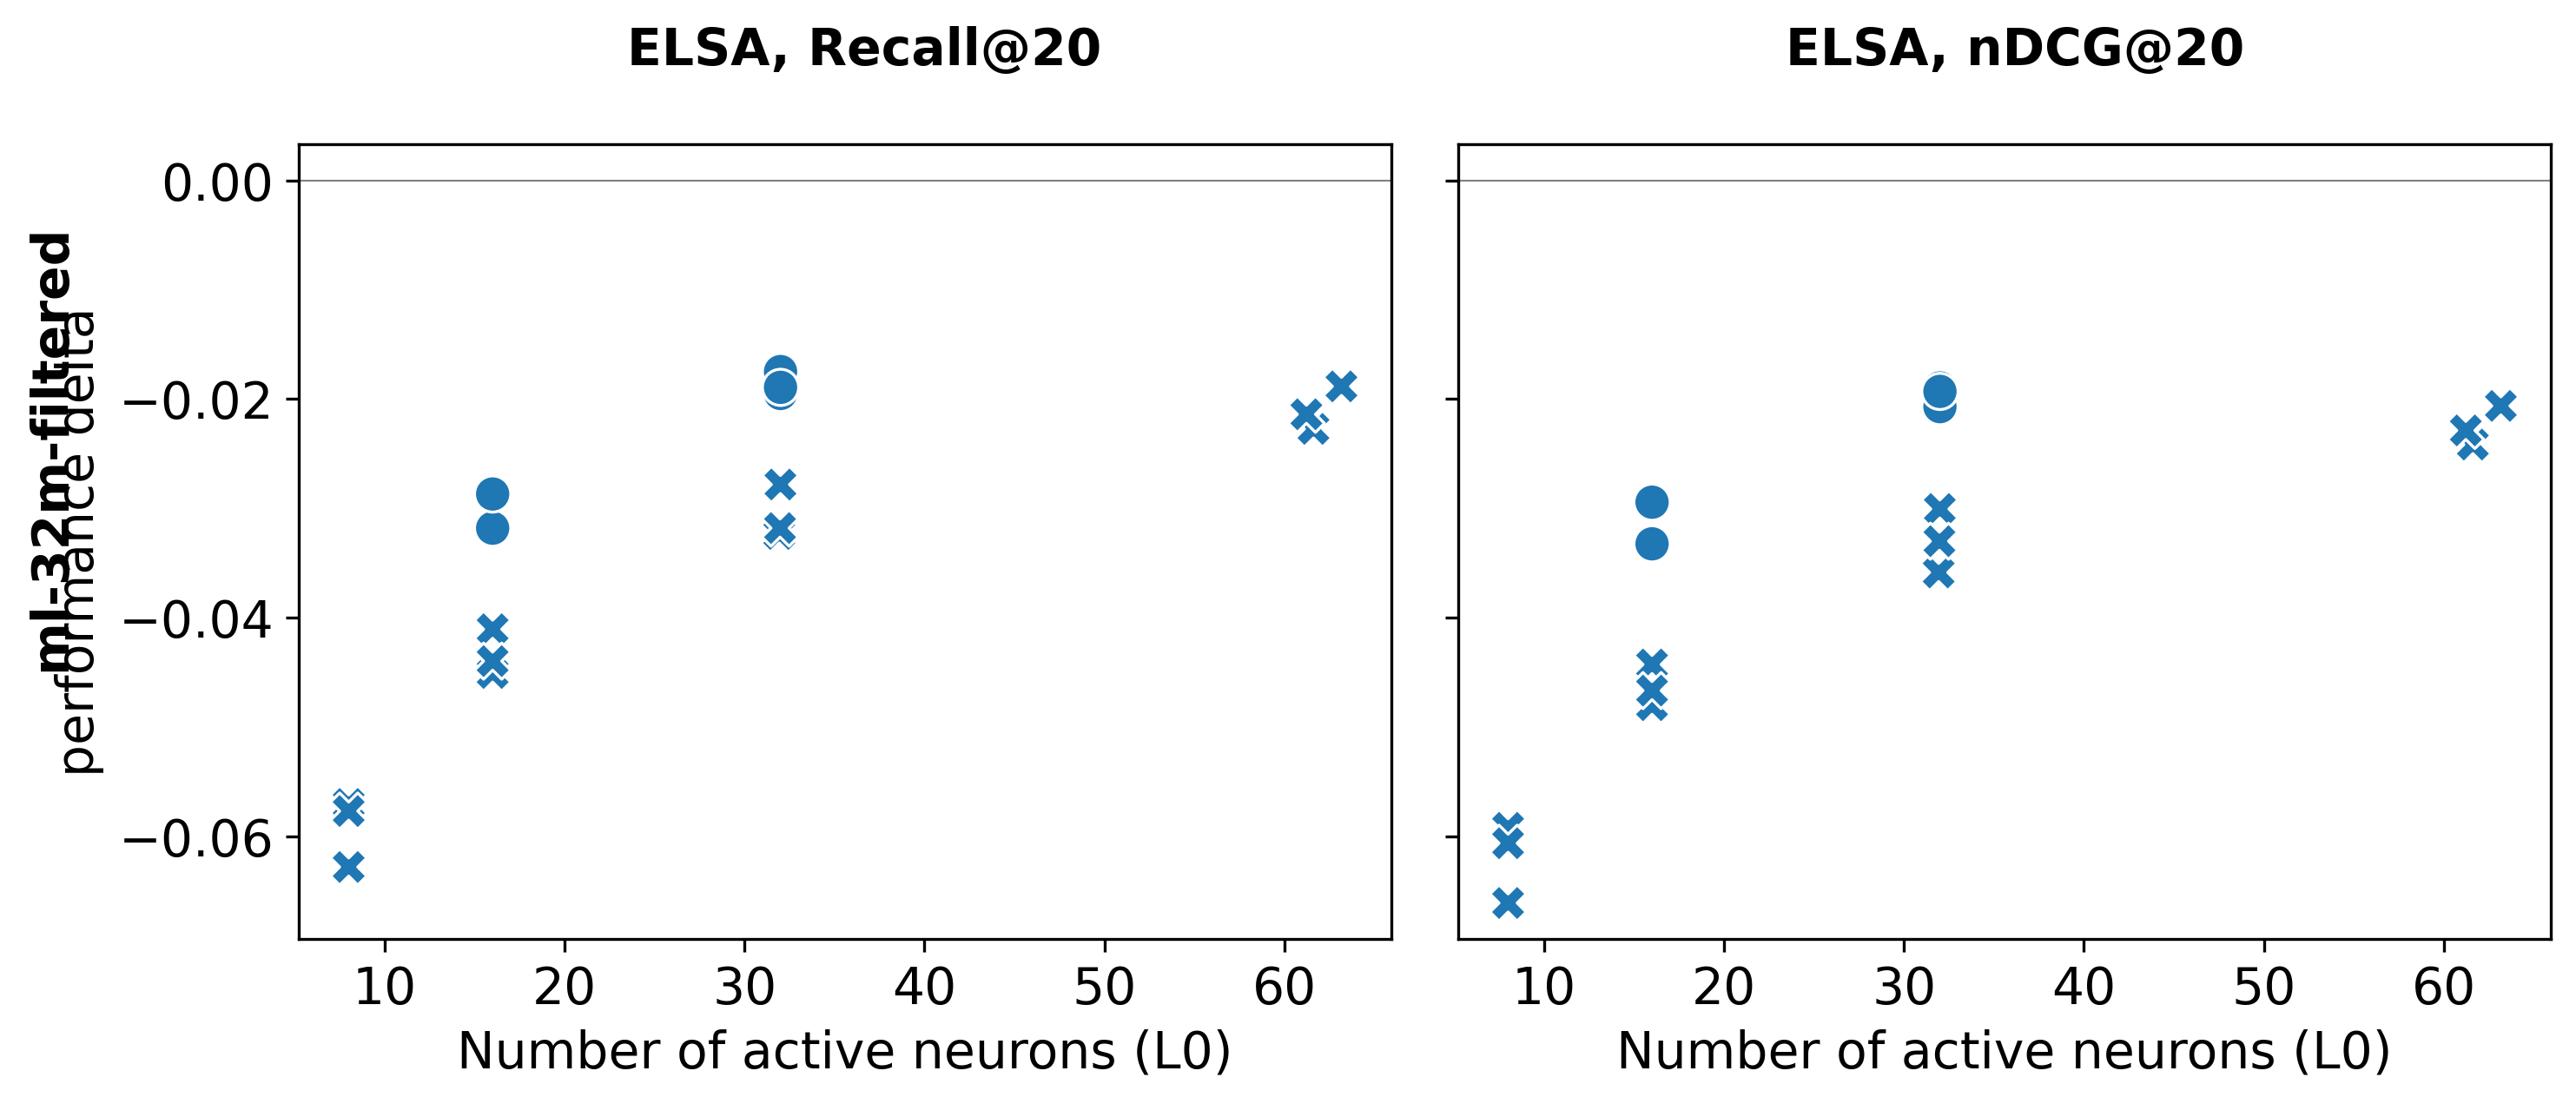

In [18]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join([exp[0], "degradation mean"])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=0, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("performance delta")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

### Relative

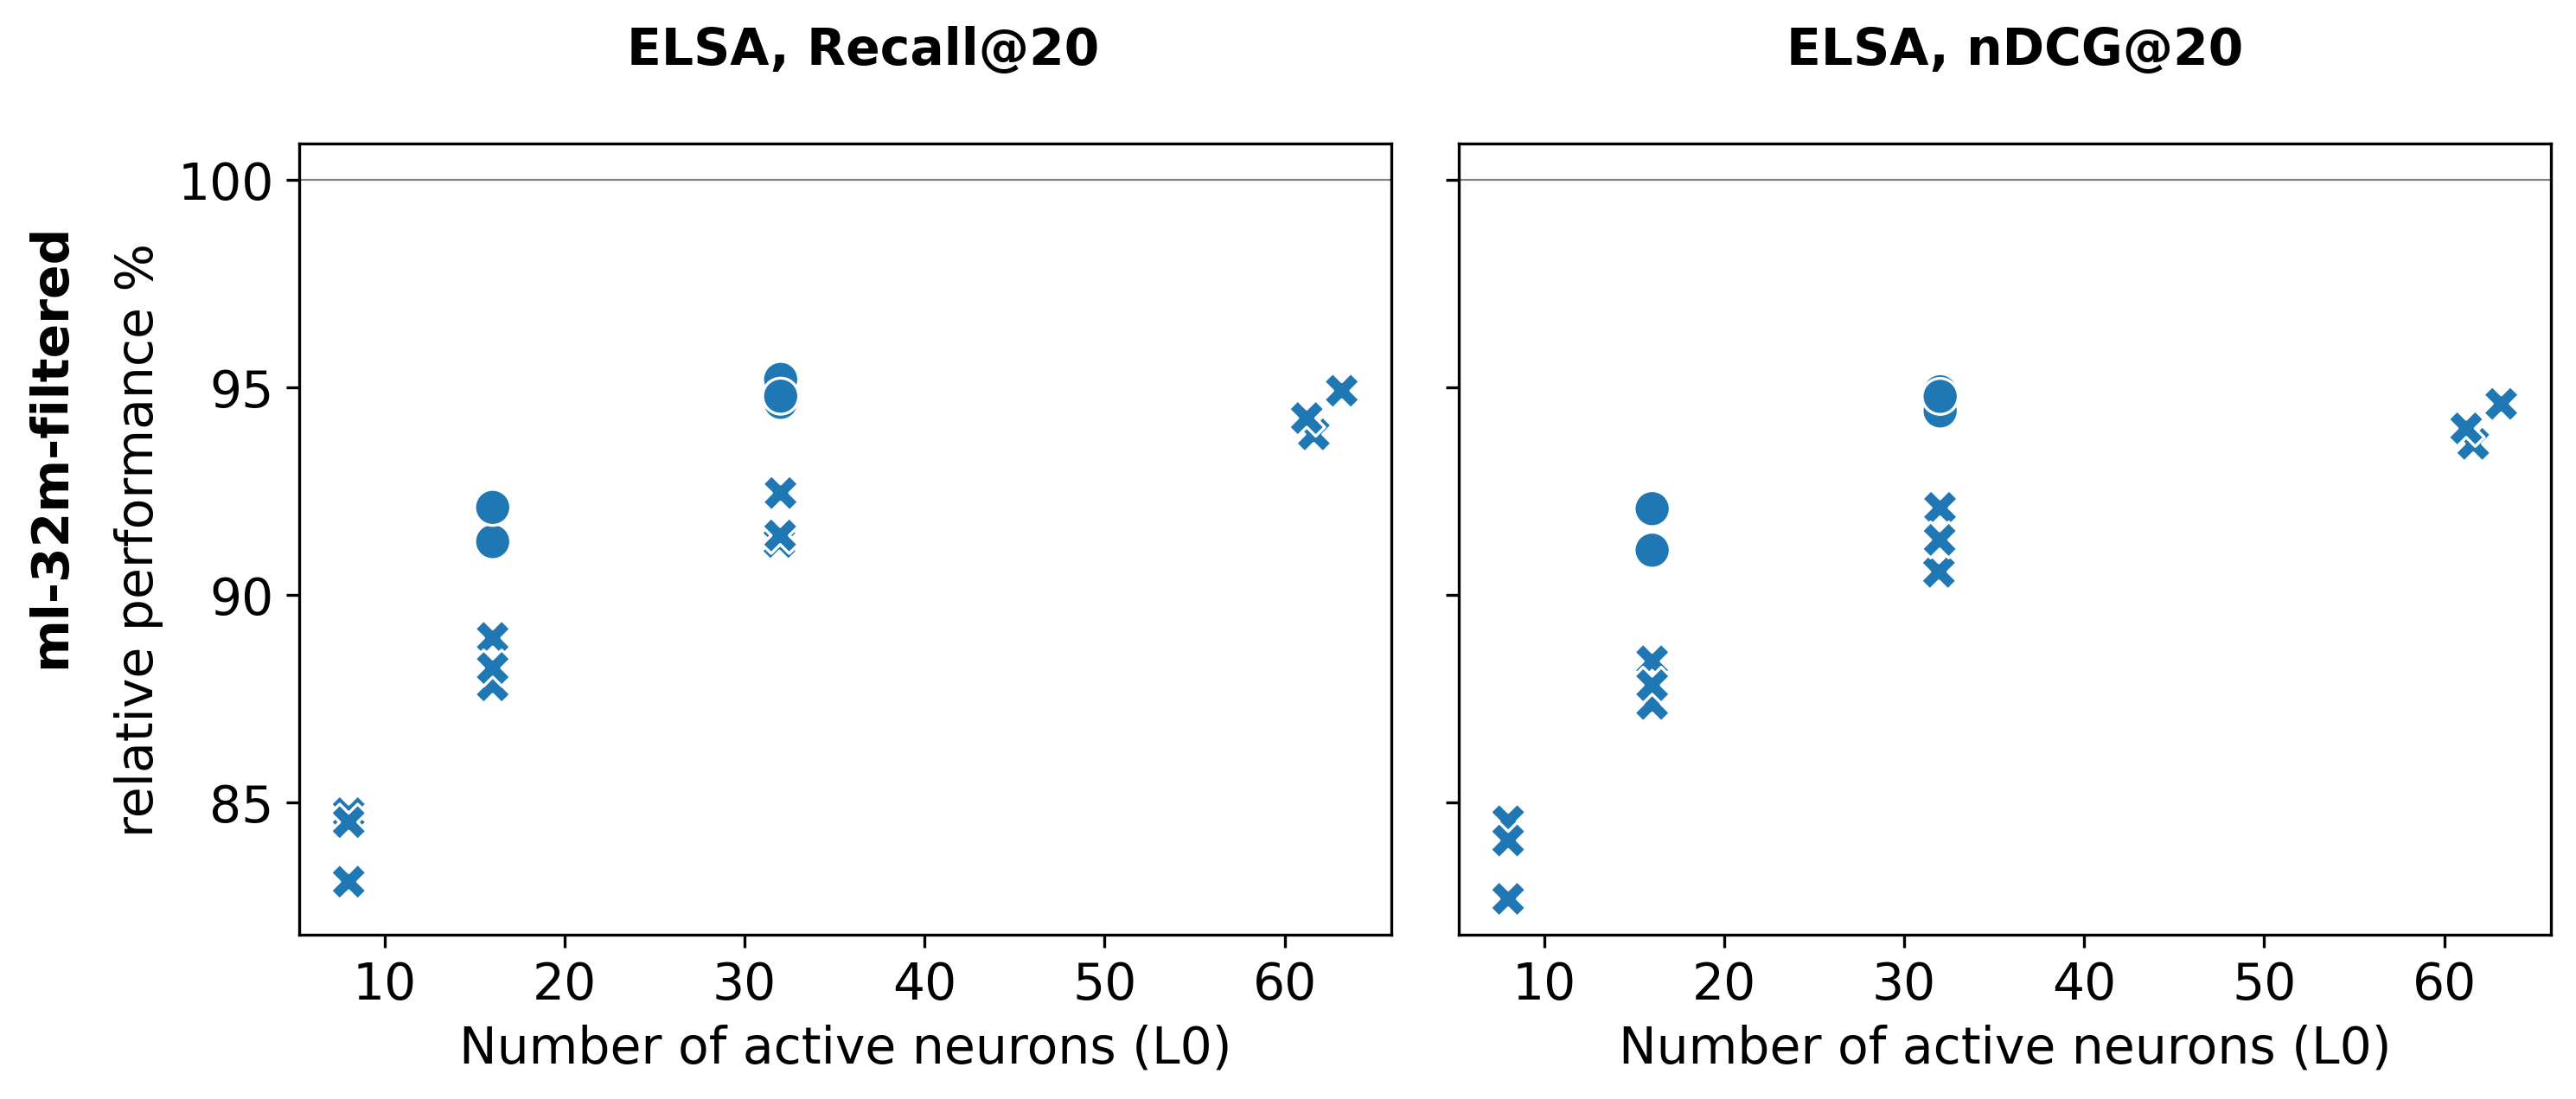

In [19]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

## Sparsity vs degradation in downstream accuracy (without sparsity outliers)

### Absolute

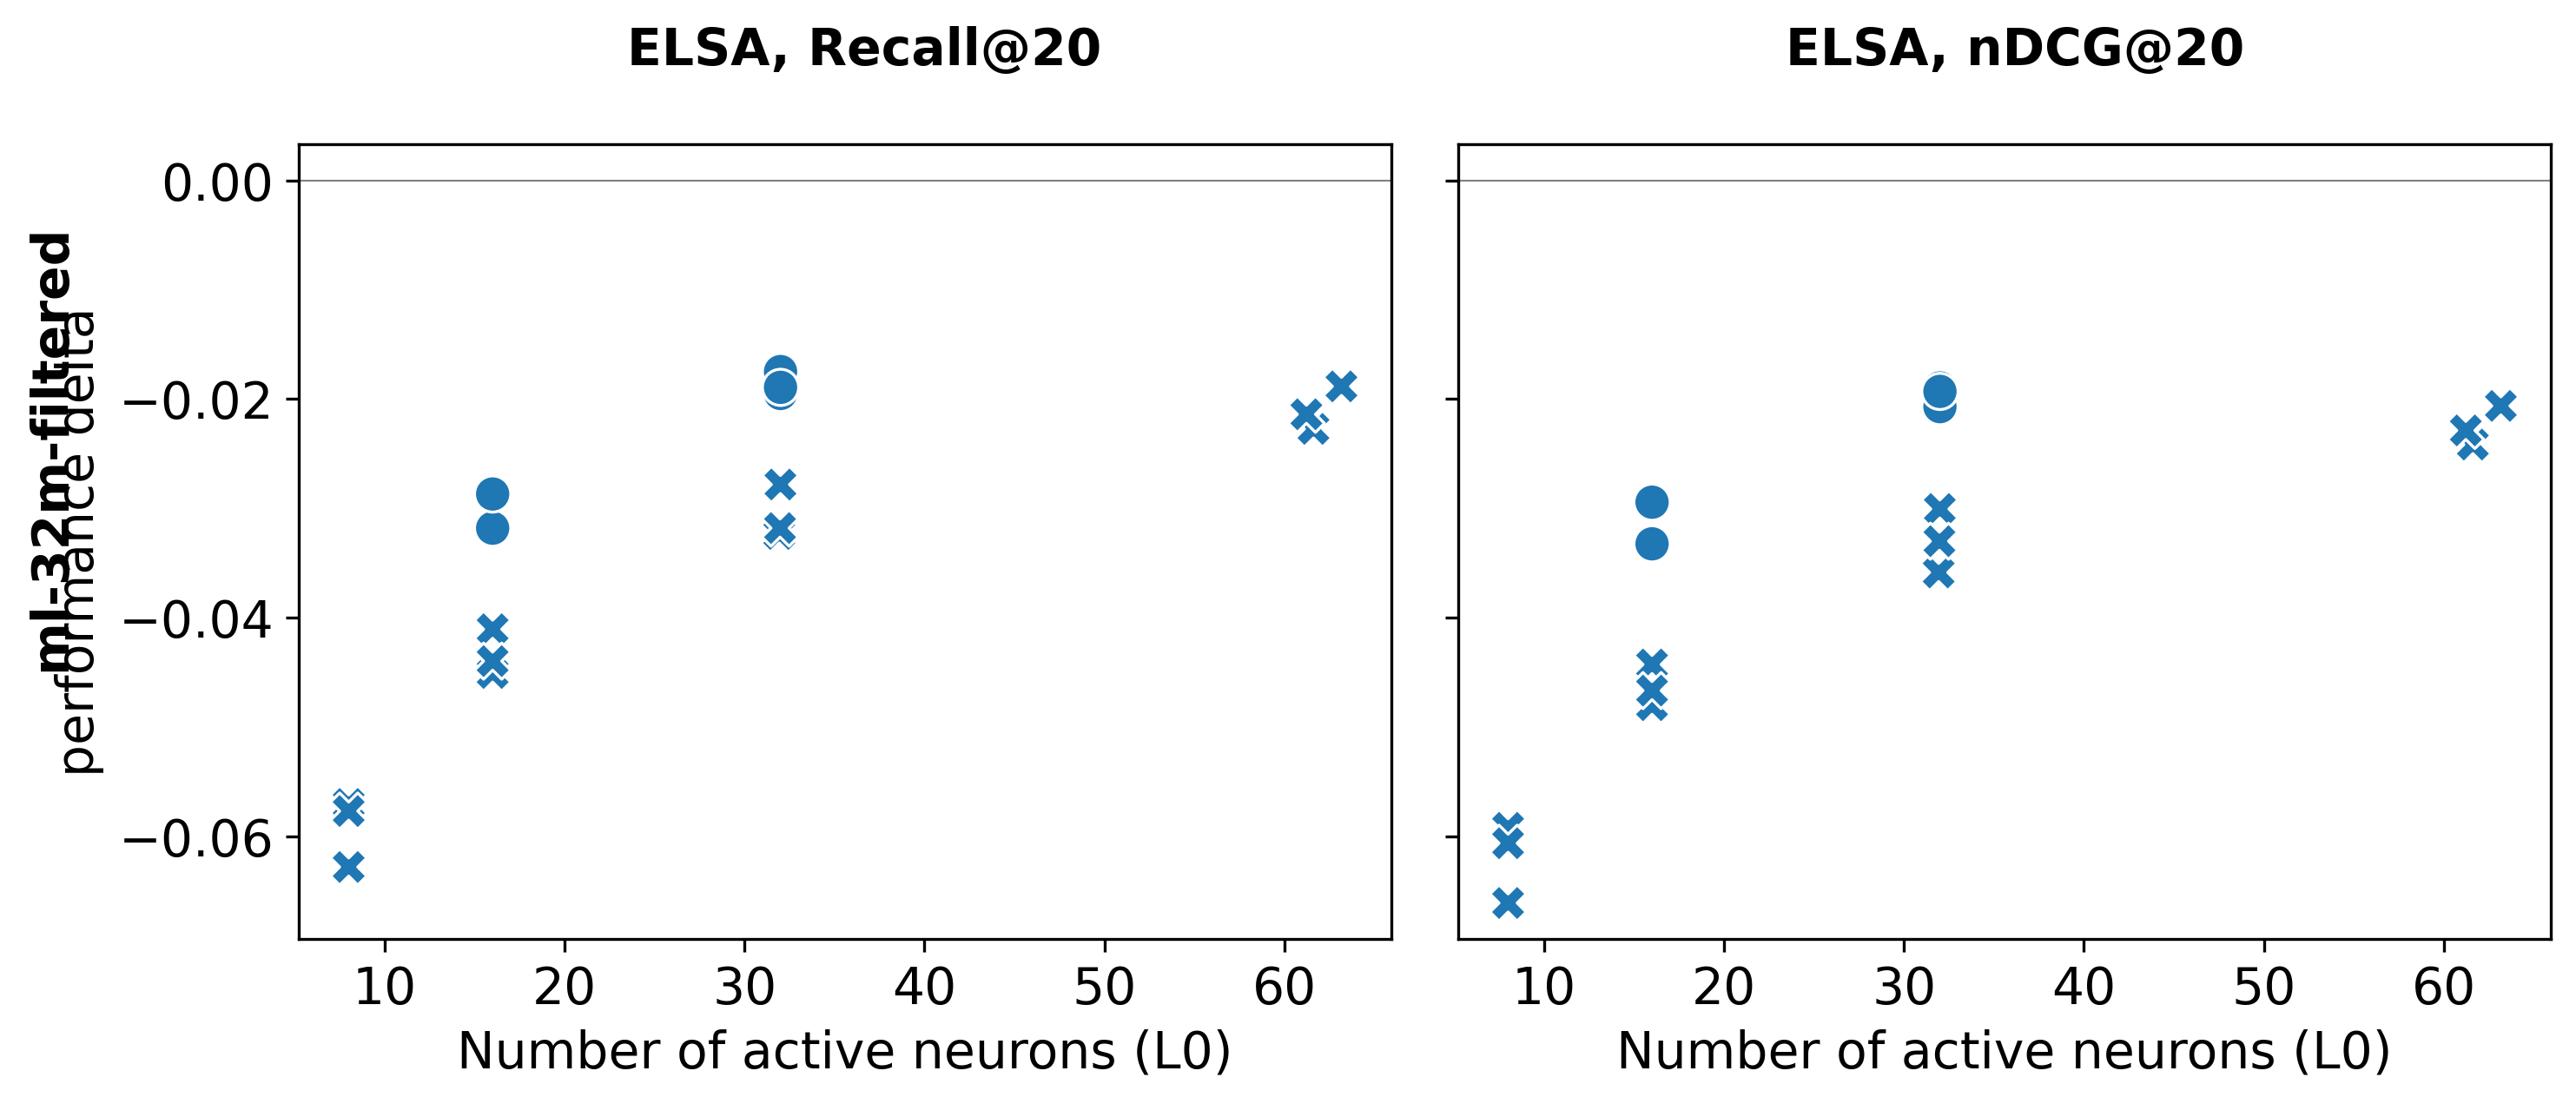

In [20]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharex=True, sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join([exp[0], "degradation mean"])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .filter((pl.col("l0 mean") >= 2) & (pl.col("l0 mean") <= 128))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=0, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("performance delta")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

### Relative performance

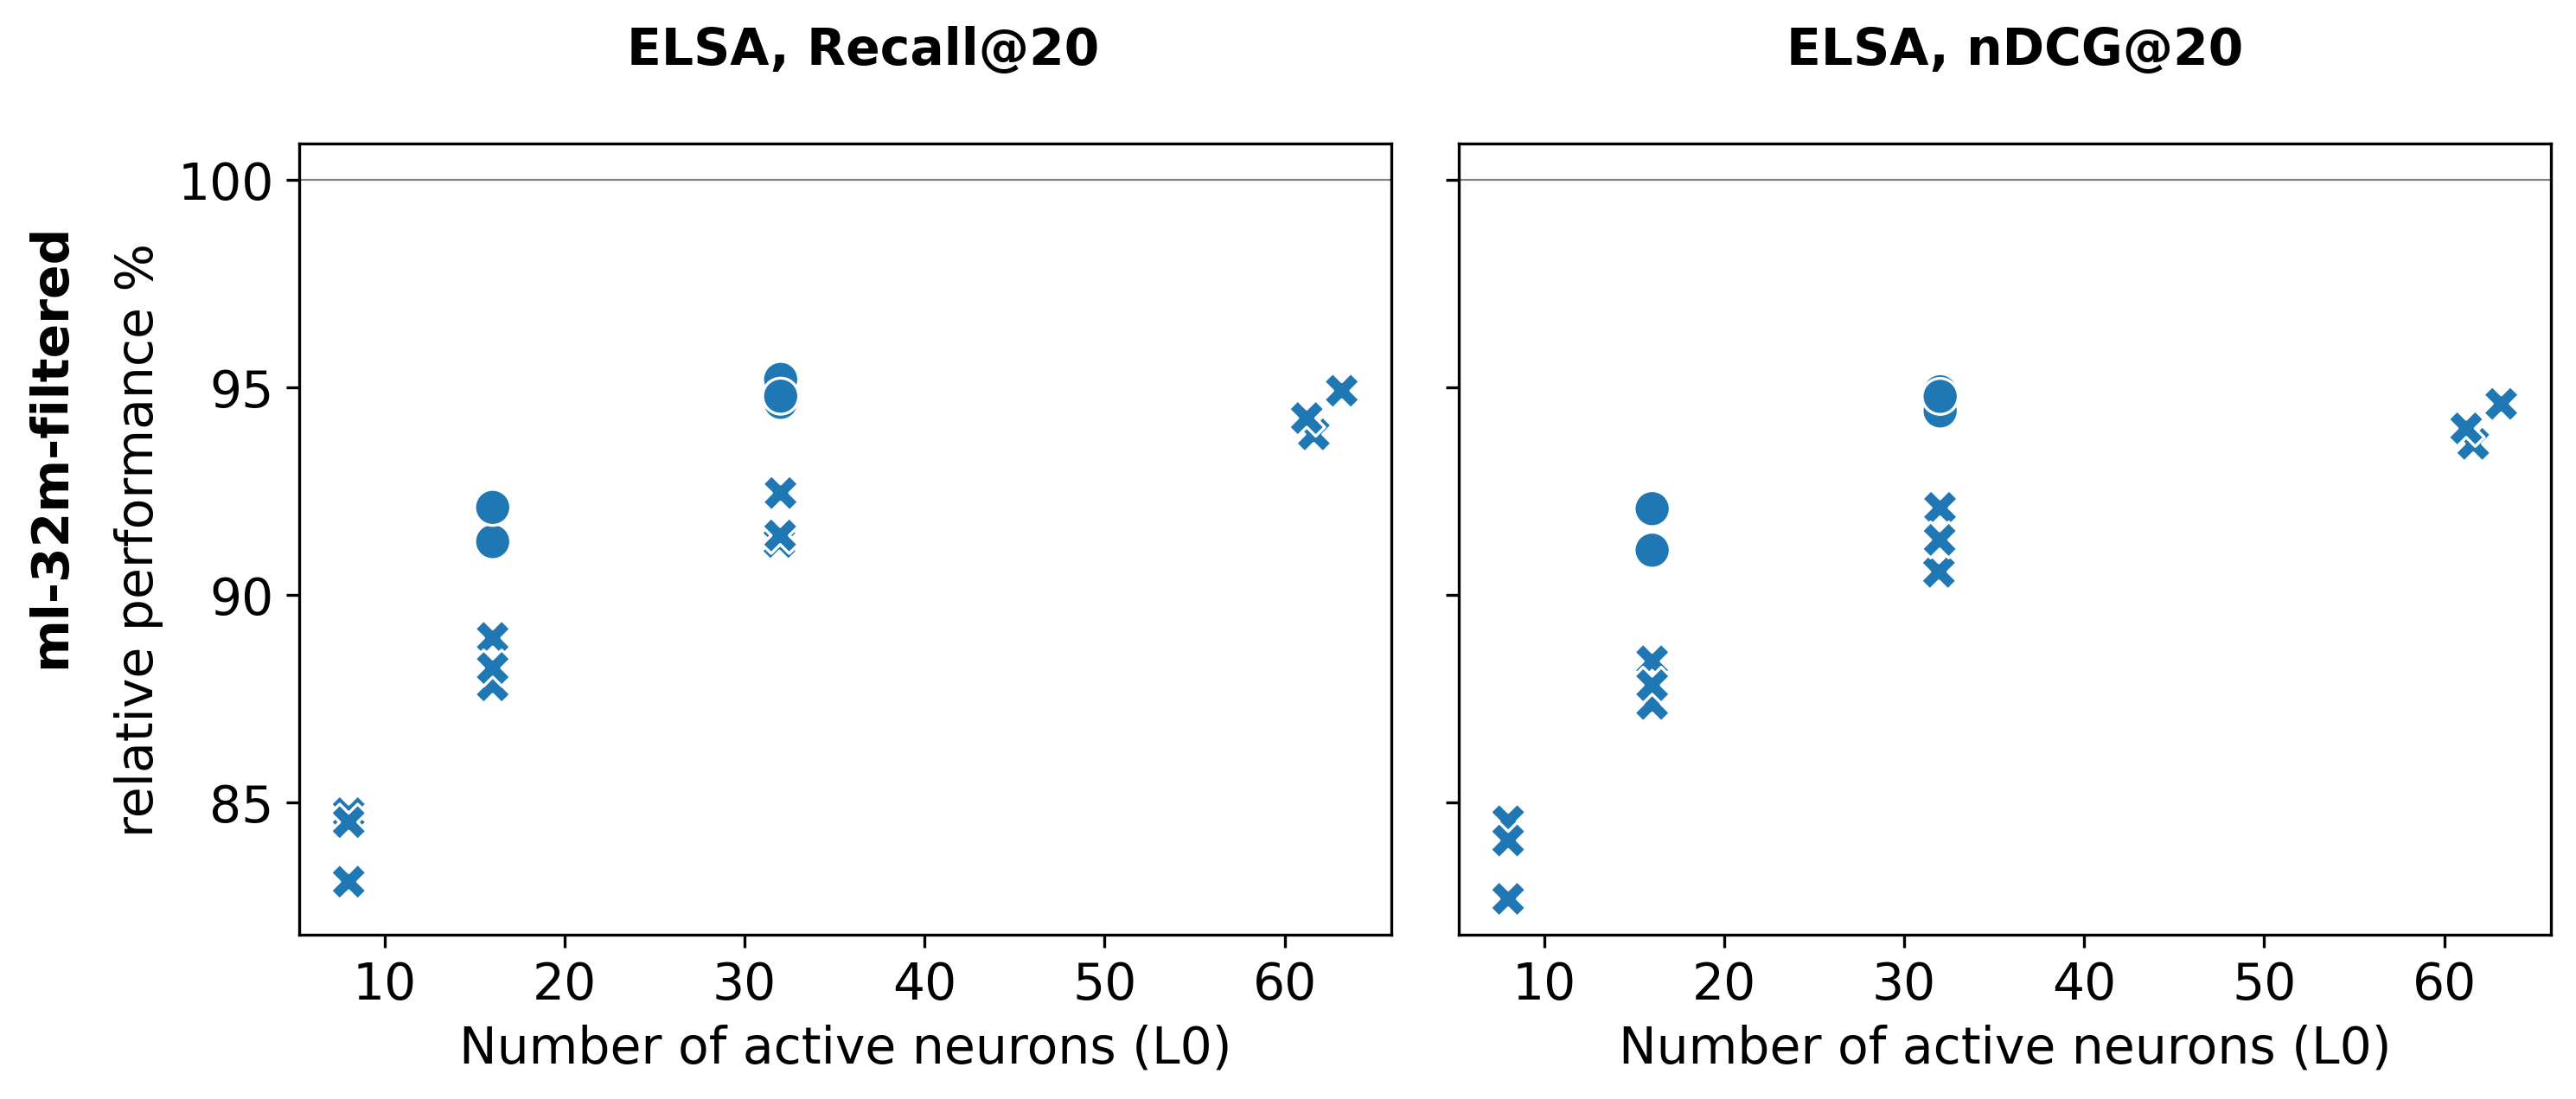

In [21]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharex=True, sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter((pl.col("l0 mean") >= 2) & (pl.col("l0 mean") <= 128))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

## Best checkpoint selection

In [22]:
def get_best_checkpoints_per_cf_model_size(dataset: str) -> pl.Series:
    return (
        result_dataframes[dataset]["val"]["sae models"]
        .with_columns(
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        )
        .with_columns(pl.col("pretrained_model_checkpoint").str.replace(r"-.*", "").alias("cf_model"))
        .with_columns(
            pl.when(pl.col("l0 mean") <= 10)
            .then(10)
            .otherwise((pl.when(pl.col("l0 mean") <= 25)).then(25).otherwise(pl.when(pl.col("l0 mean") <= 50).then(50).otherwise(100)))
            .alias("sparsity bucket")
        )
        .sort("relative ndcg", descending=True)
        .group_by("cf_model", "model_class", "cf_model_size", "sparsity bucket")
        .first()["checkpoint"]
    )

# Test results

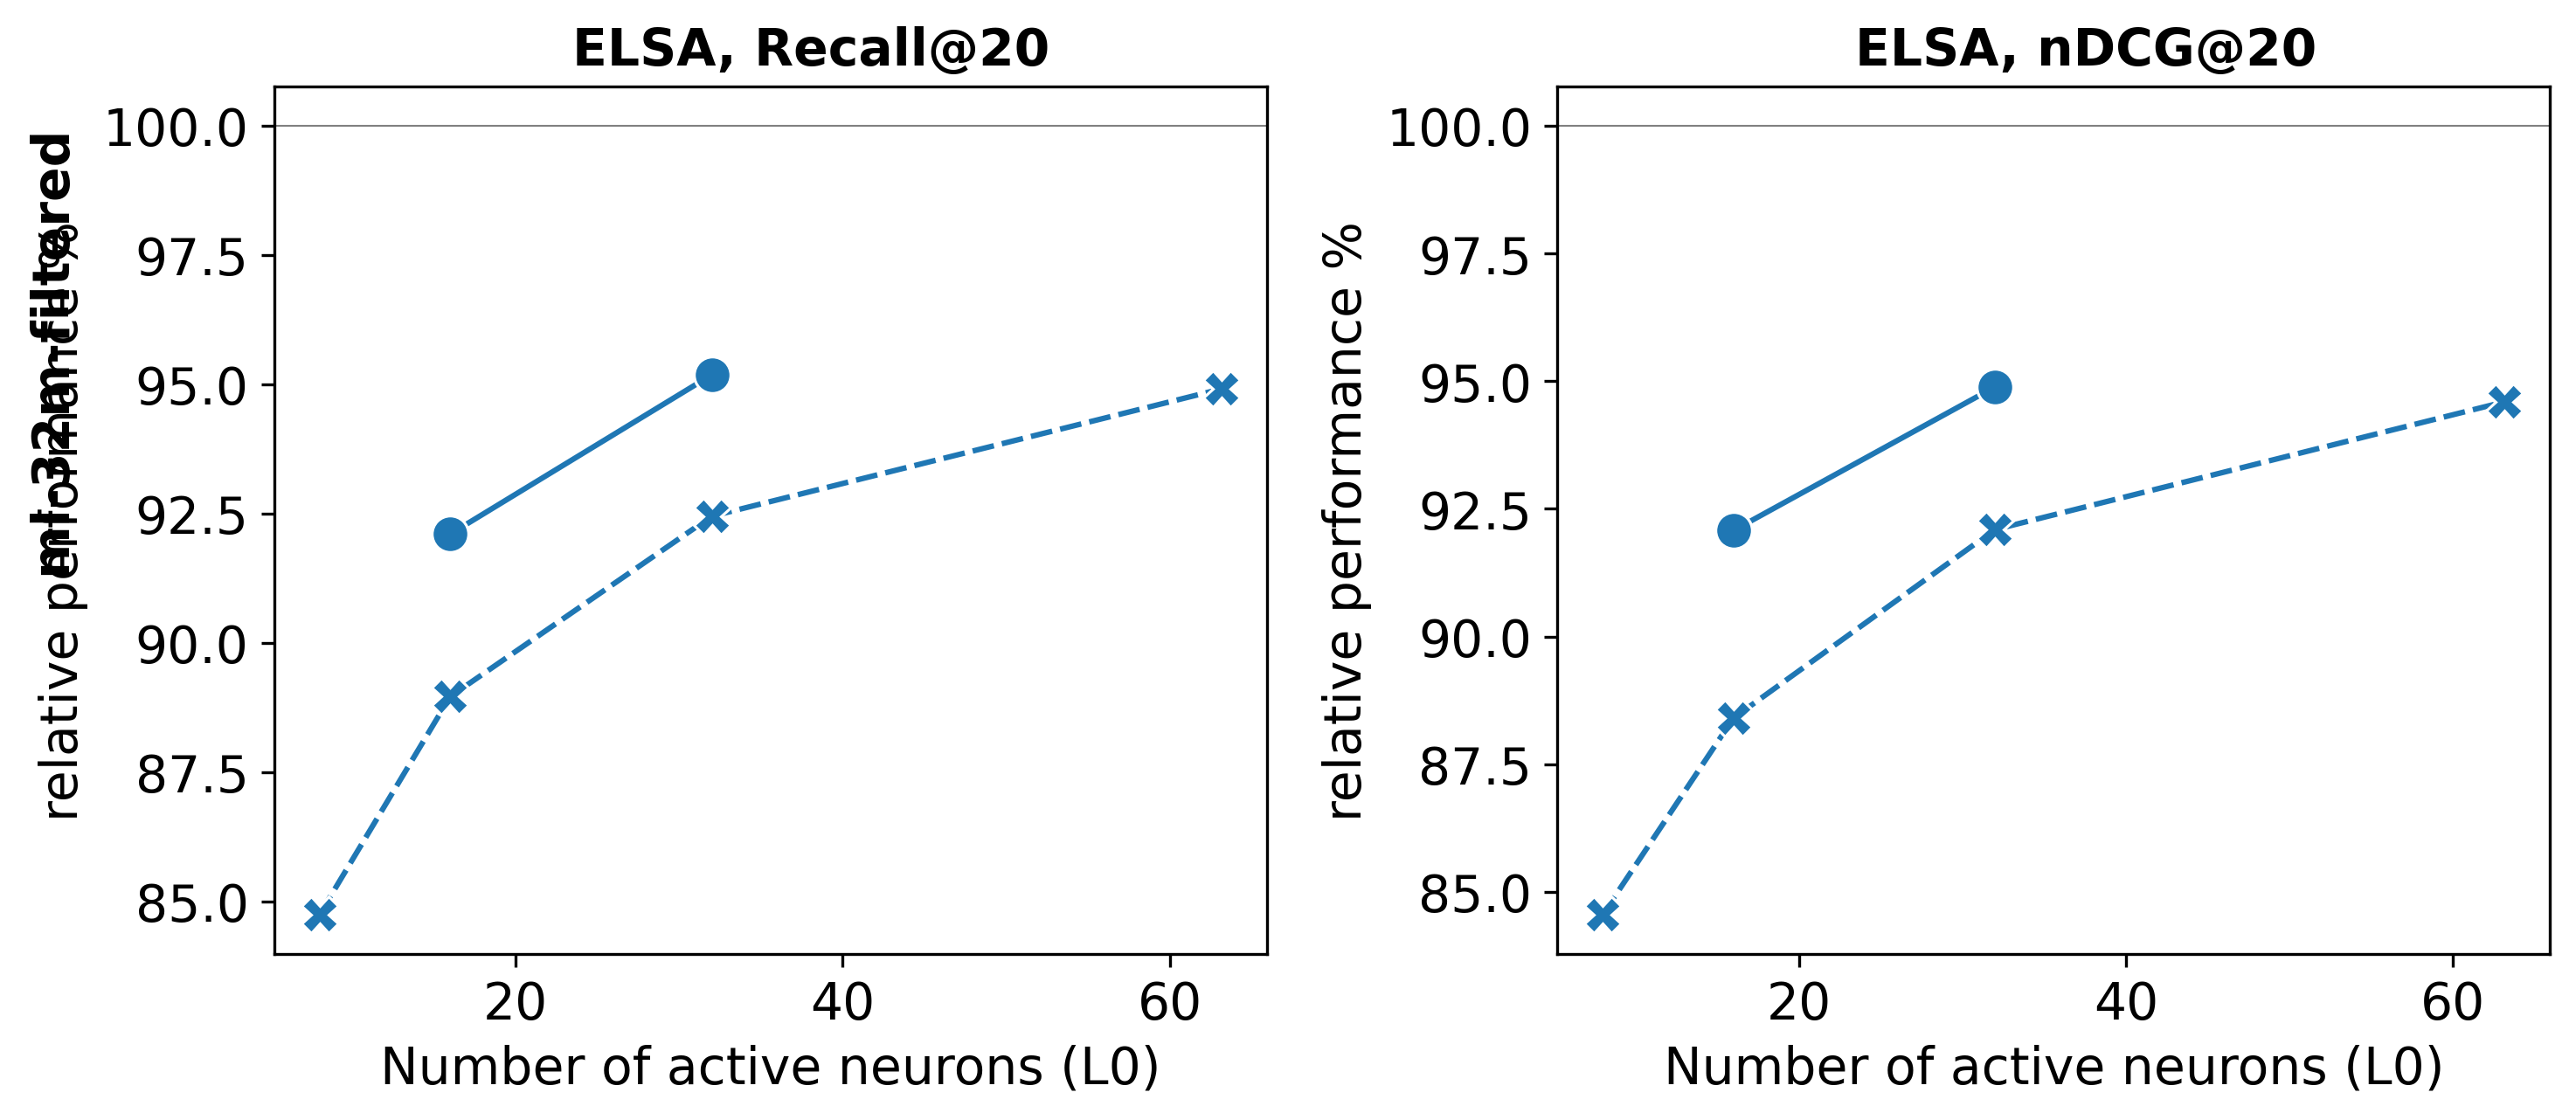

In [26]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.lineplot(
            result_dataframes[dataset]["test"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.45), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.025), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

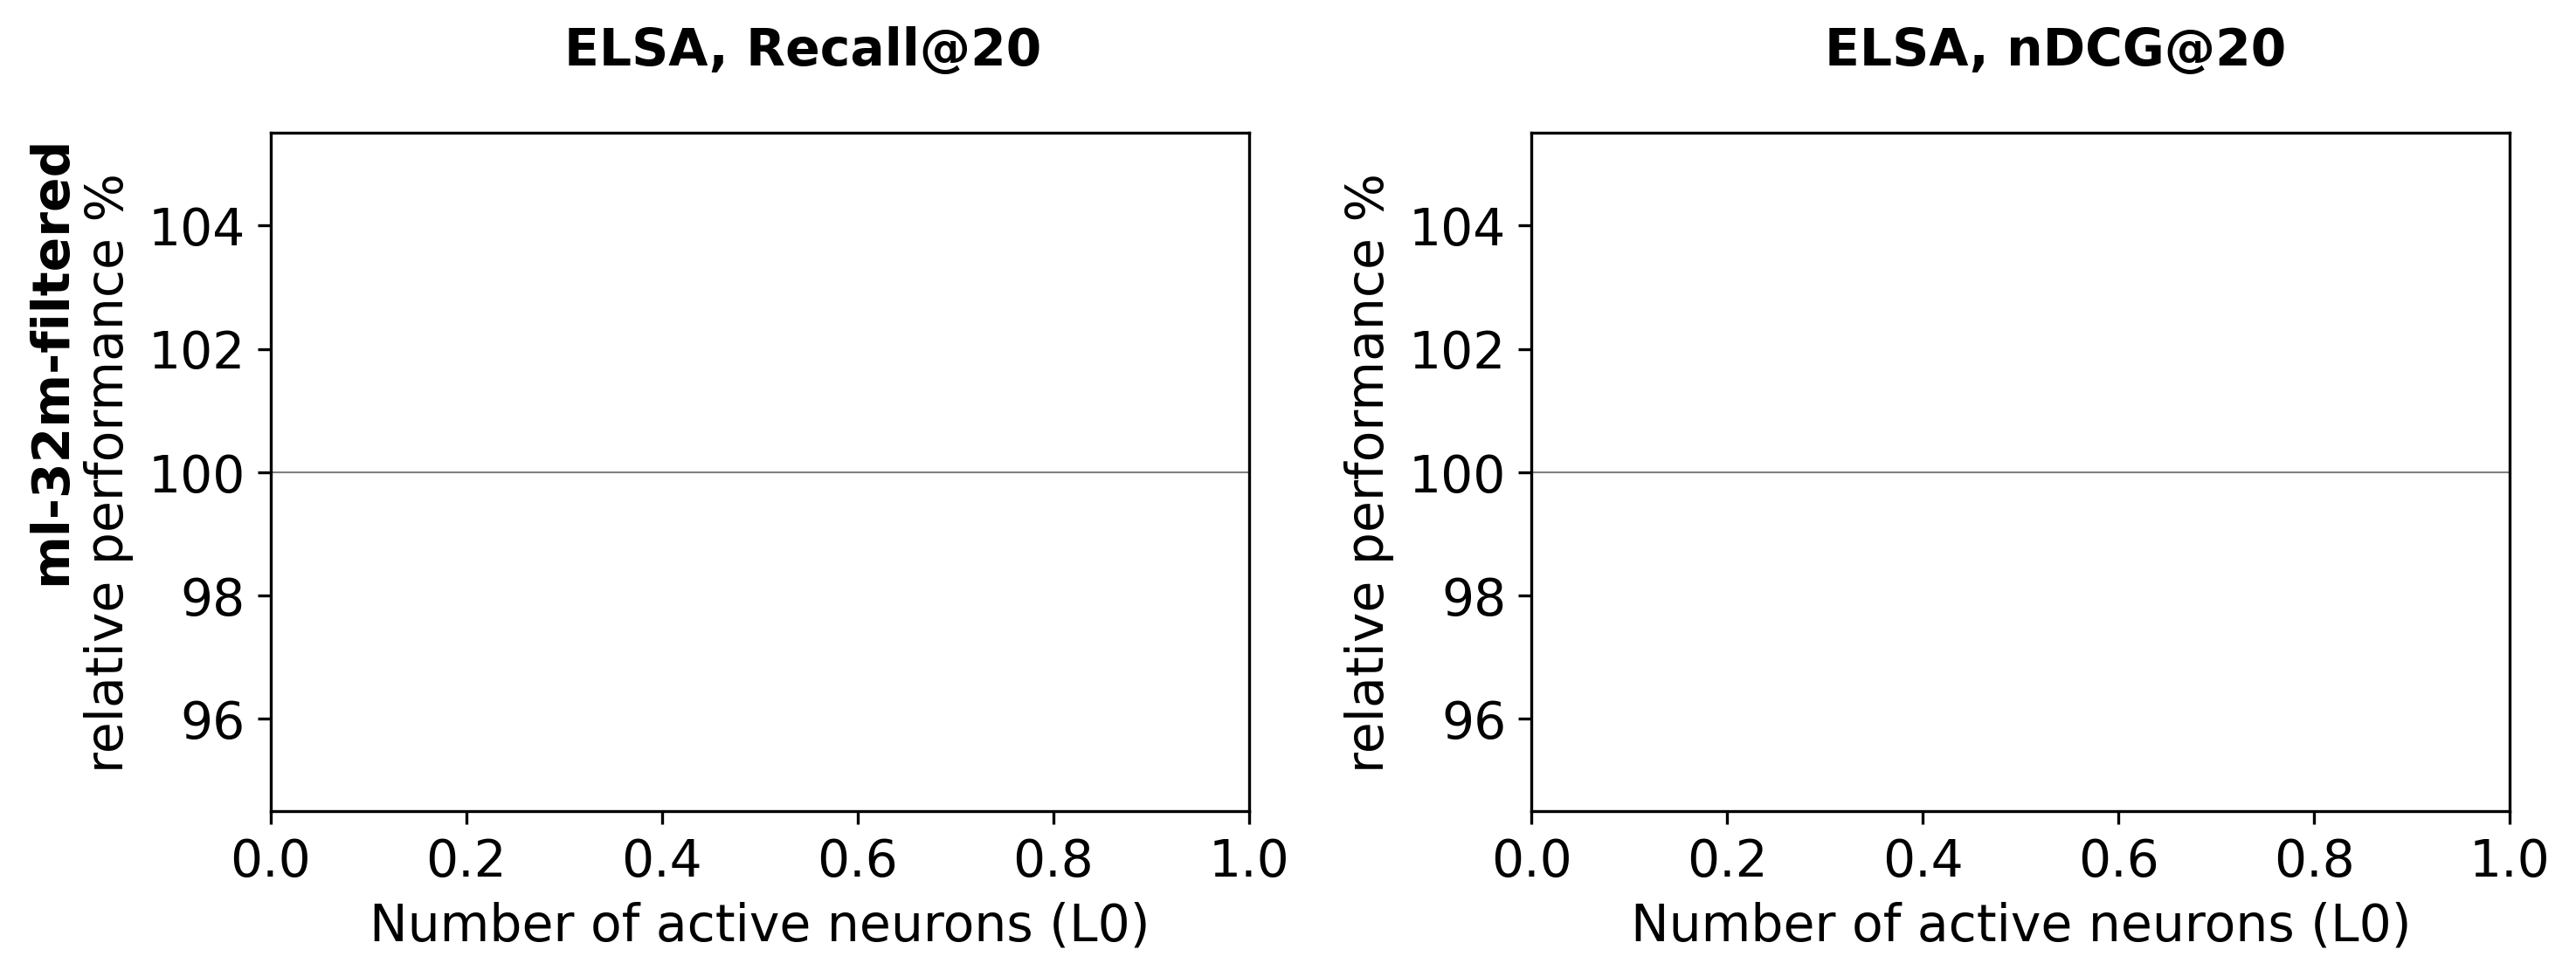

In [27]:
cf_model_size = 1  # smallest CF models

n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.lineplot(
            result_dataframes[dataset]["test"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .filter(pl.col("cf_model_size") == cf_model_size)
            .sort(by=["model_class"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

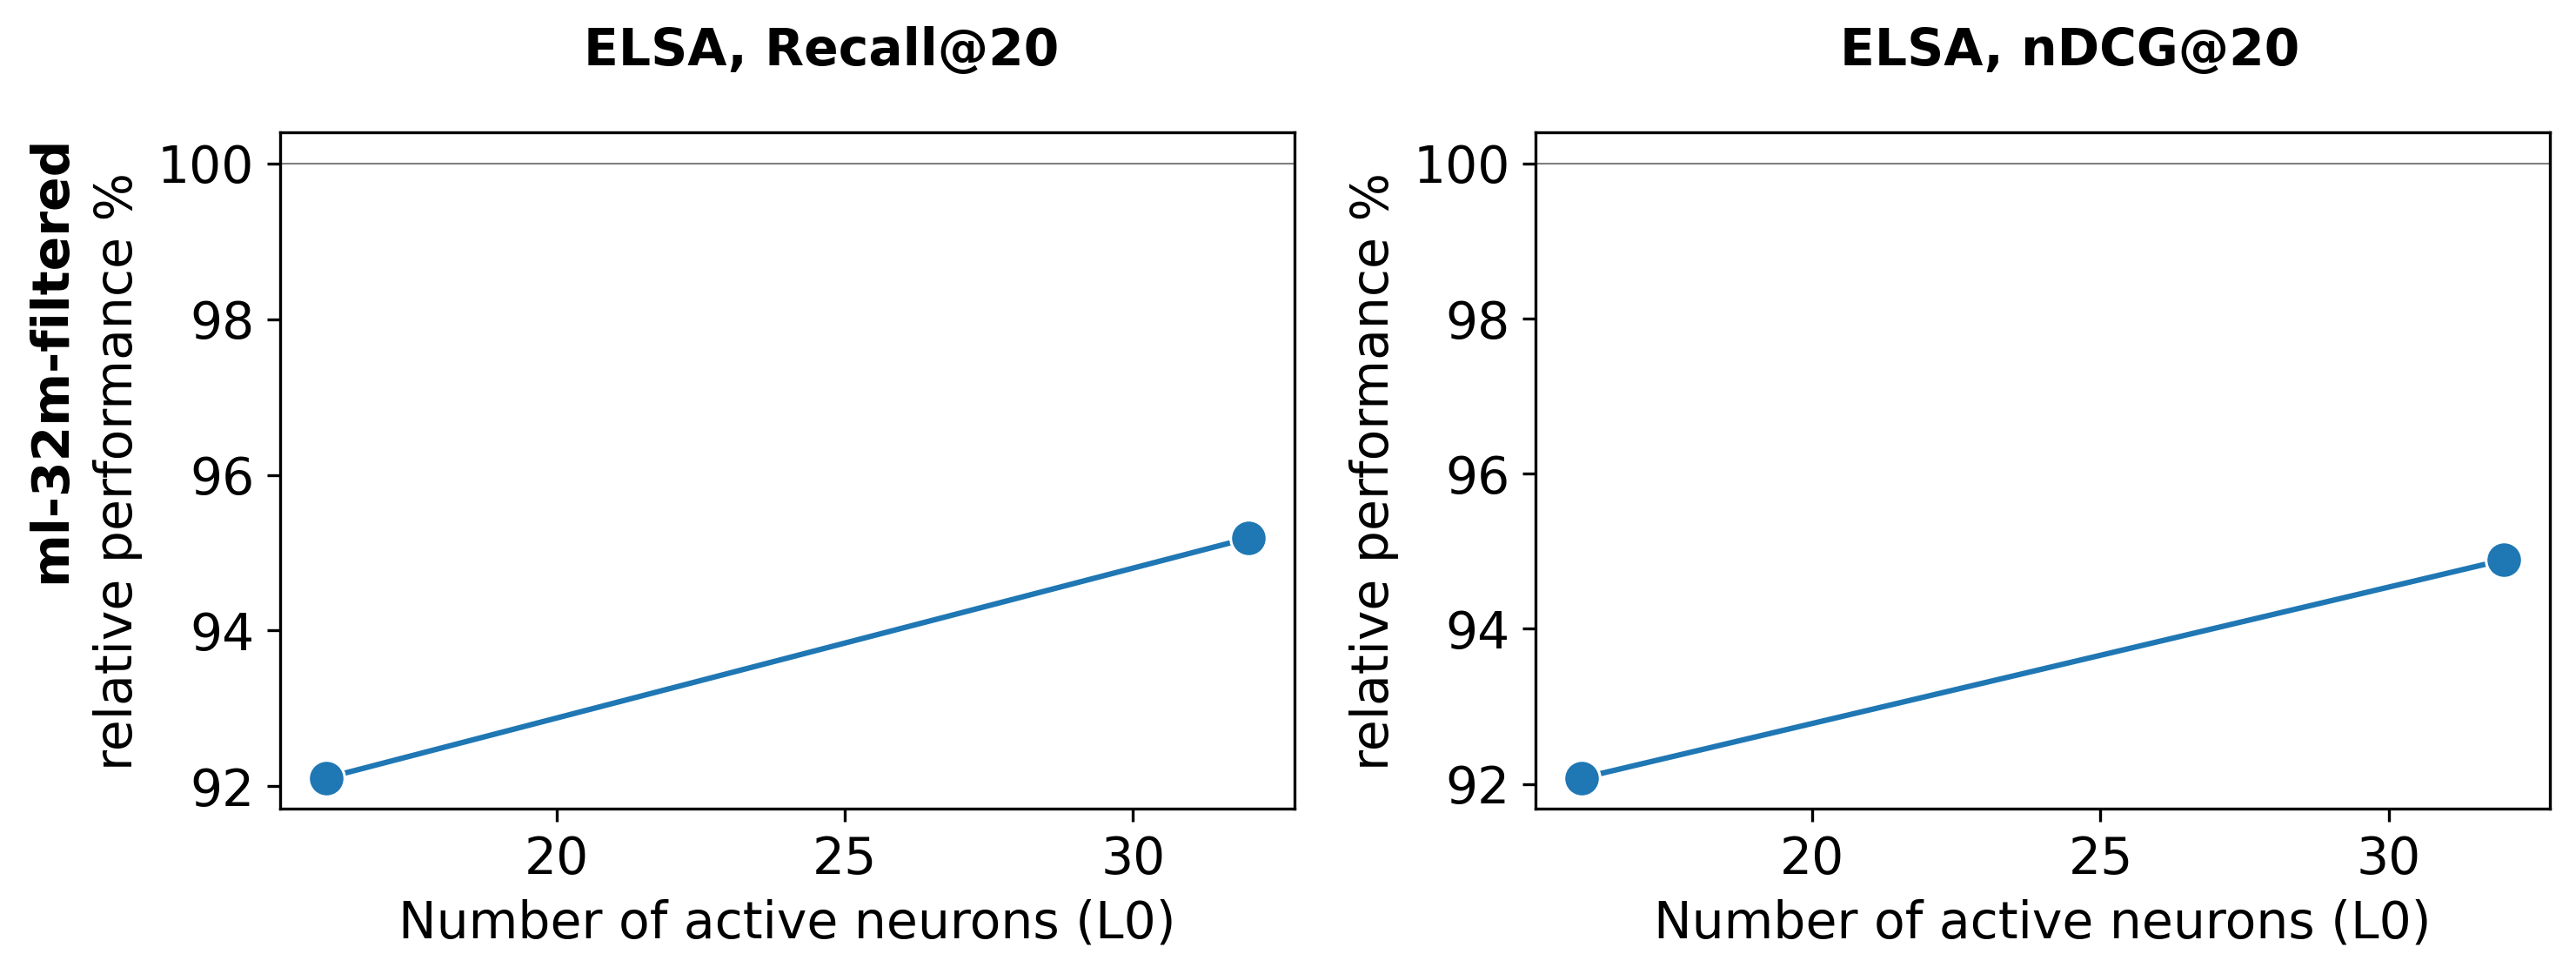

In [28]:
cf_model_size = 2  # middle CF models

n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.lineplot(
            result_dataframes[dataset]["test"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .filter(pl.col("cf_model_size") == cf_model_size)
            .sort(by=["model_class"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

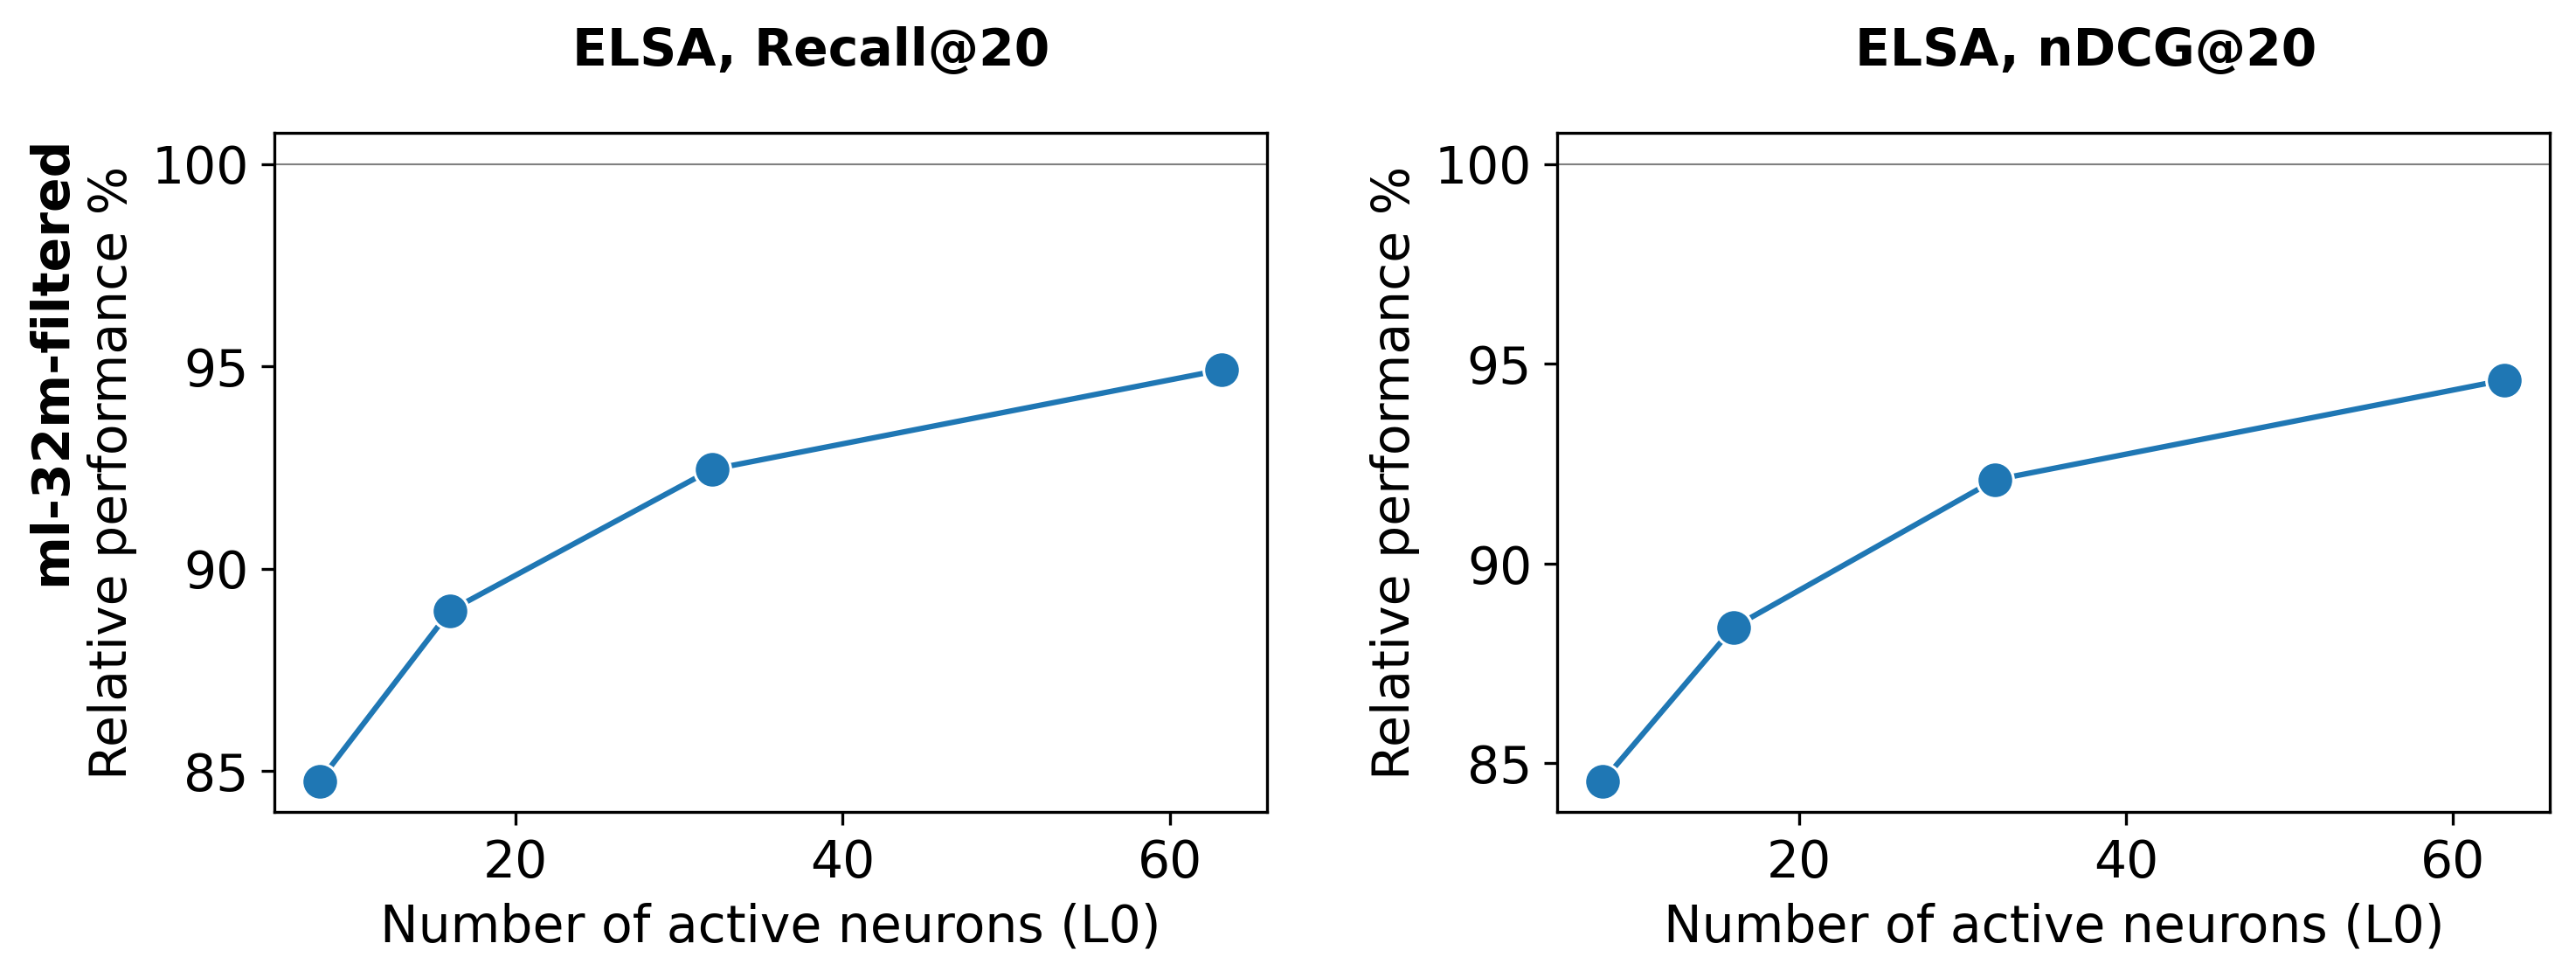

In [29]:
cf_model_size = 4  # largest CF models

n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.lineplot(
            result_dataframes[dataset]["test"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .filter(pl.col("cf_model_size") == cf_model_size)
            .sort(by=["model_class"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="model_class",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("Relative performance %")

for i, dataset in enumerate(DATASETS):
    axes[i, 0].annotate(dataset, xy=(-0.25, 0.35), xycoords="axes fraction", rotation=90, fontsize=14, fontweight="semibold")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

In [30]:
result_dataframes[DATASETS[0]]["val"]["sae models"].filter((pl.col("k") == 16) & (pl.col("embedding_dim") == 8192) & (pl.col("scaling_factor") == 8))

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,f64


In [15]:
result_dataframes[DATASETS[0]]["val"]["sae models"].filter((pl.col("k") == 16) & (pl.col("embedding_dim") == 4096) & (pl.col("scaling_factor") == 4))

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,f64
"""TopKSAE-4096-4e0e5bcd.json""","""ML-25M""","""ELSA-1024-10977915.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.877366,0.000642,15.99011,0.001694,153,0.370635,0.001916,-0.023589,0.000835,0.334284,0.001684,-0.023209,0.000647,1024,4,"""ELSA""",2.0
"""TopKSAE-4096-4b8d3099.json""","""ML-25M""","""MultVAE-1024-2701bf6a.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.806153,0.000655,15.999938,0.000062,728,0.272425,0.001739,-0.105101,0.001422,0.233978,0.00151,-0.101273,0.001257,1024,4,"""MultVAE""",4.0
"""TopKSAE-4096-9e7a4cd7.json""","""ML-25M""","""MultVAE-1024-2701bf6a.ckpt""","""sae""","""TopKSAE""",4096,"""L2""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.804406,0.000637,16.0,0.0,801,0.299697,0.001808,-0.078294,0.001314,0.235336,0.001399,-0.099344,0.001184,1024,4,"""MultVAE""",4.0
"""TopKSAE-4096-118aa0b6.json""","""ML-25M""","""ELSA-1024-10977915.ckpt""","""sae""","""TopKSAE""",4096,"""L2""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.858634,0.000727,16.0,0.0,422,0.363741,0.001908,-0.029082,0.000941,0.327143,0.001686,-0.030479,0.000753,1024,4,"""ELSA""",2.0


In [314]:
dataset = DATASETS[0]
input_dim = 1024

In [31]:
result_dataframes[dataset]["test"]["sae models"].select(
    ["embedding_dim", "k", "cf_model_size", "checkpoint"]
).sort(["embedding_dim", "k"])

embedding_dim,k,cf_model_size,checkpoint
i64,i64,f64,str
2048,16,2.0,"""TopKSAE-2048-1bdbdbeb.json"""
2048,32,2.0,"""TopKSAE-2048-088b6417.json"""
4096,8,4.0,"""TopKSAE-4096-1c7e8e64.json"""
4096,16,2.0,"""TopKSAE-4096-225fea36.json"""
4096,16,4.0,"""TopKSAE-4096-394ab82e.json"""
…,…,…,…
8192,64,4.0,"""TopKSAE-8192-c74a9ecc.json"""
16384,8,4.0,"""TopKSAE-16384-337b98a3.json"""
16384,16,4.0,"""TopKSAE-16384-ef43284e.json"""


# Effect of SAE scaling factor

In [41]:
dataset = DATASETS[0]
split = "val"

sae_table = result_dataframes[dataset][split]["sae models"]
available_input_dims = sorted(sae_table.select("input_dim").unique().to_series().to_list())
if not available_input_dims:
    raise ValueError(f"No SAE rows found for dataset={dataset}, split={split}.")

# Use explicit input_dim if already set; otherwise pick the largest available one.
if "input_dim" not in globals() or input_dim is None:
    input_dim = int(available_input_dims[-1])
elif input_dim not in available_input_dims:
    raise ValueError(f"input_dim={input_dim} is not available. Choose one of: {available_input_dims}")

_df = (
    sae_table
    .filter(pl.col("input_dim") == input_dim)
    .with_columns(
        [
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        ]
    )
    .sort(by=["model_class", "cf_model"])
)

print(f"Using input_dim={input_dim}. Available input_dims={available_input_dims}")
print(f"Rows in _df: {_df.height}")

Using input_dim=2048. Available input_dims=[1024, 2048]
Rows in _df: 12


## Active neurons per input

/tmp/ipykernel_14733/1036458025.py:14: UserWarning: The palette list has more values (9) than needed (1), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_14733/1036458025.py:49: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/1036458025.py:49: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/1036458025.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


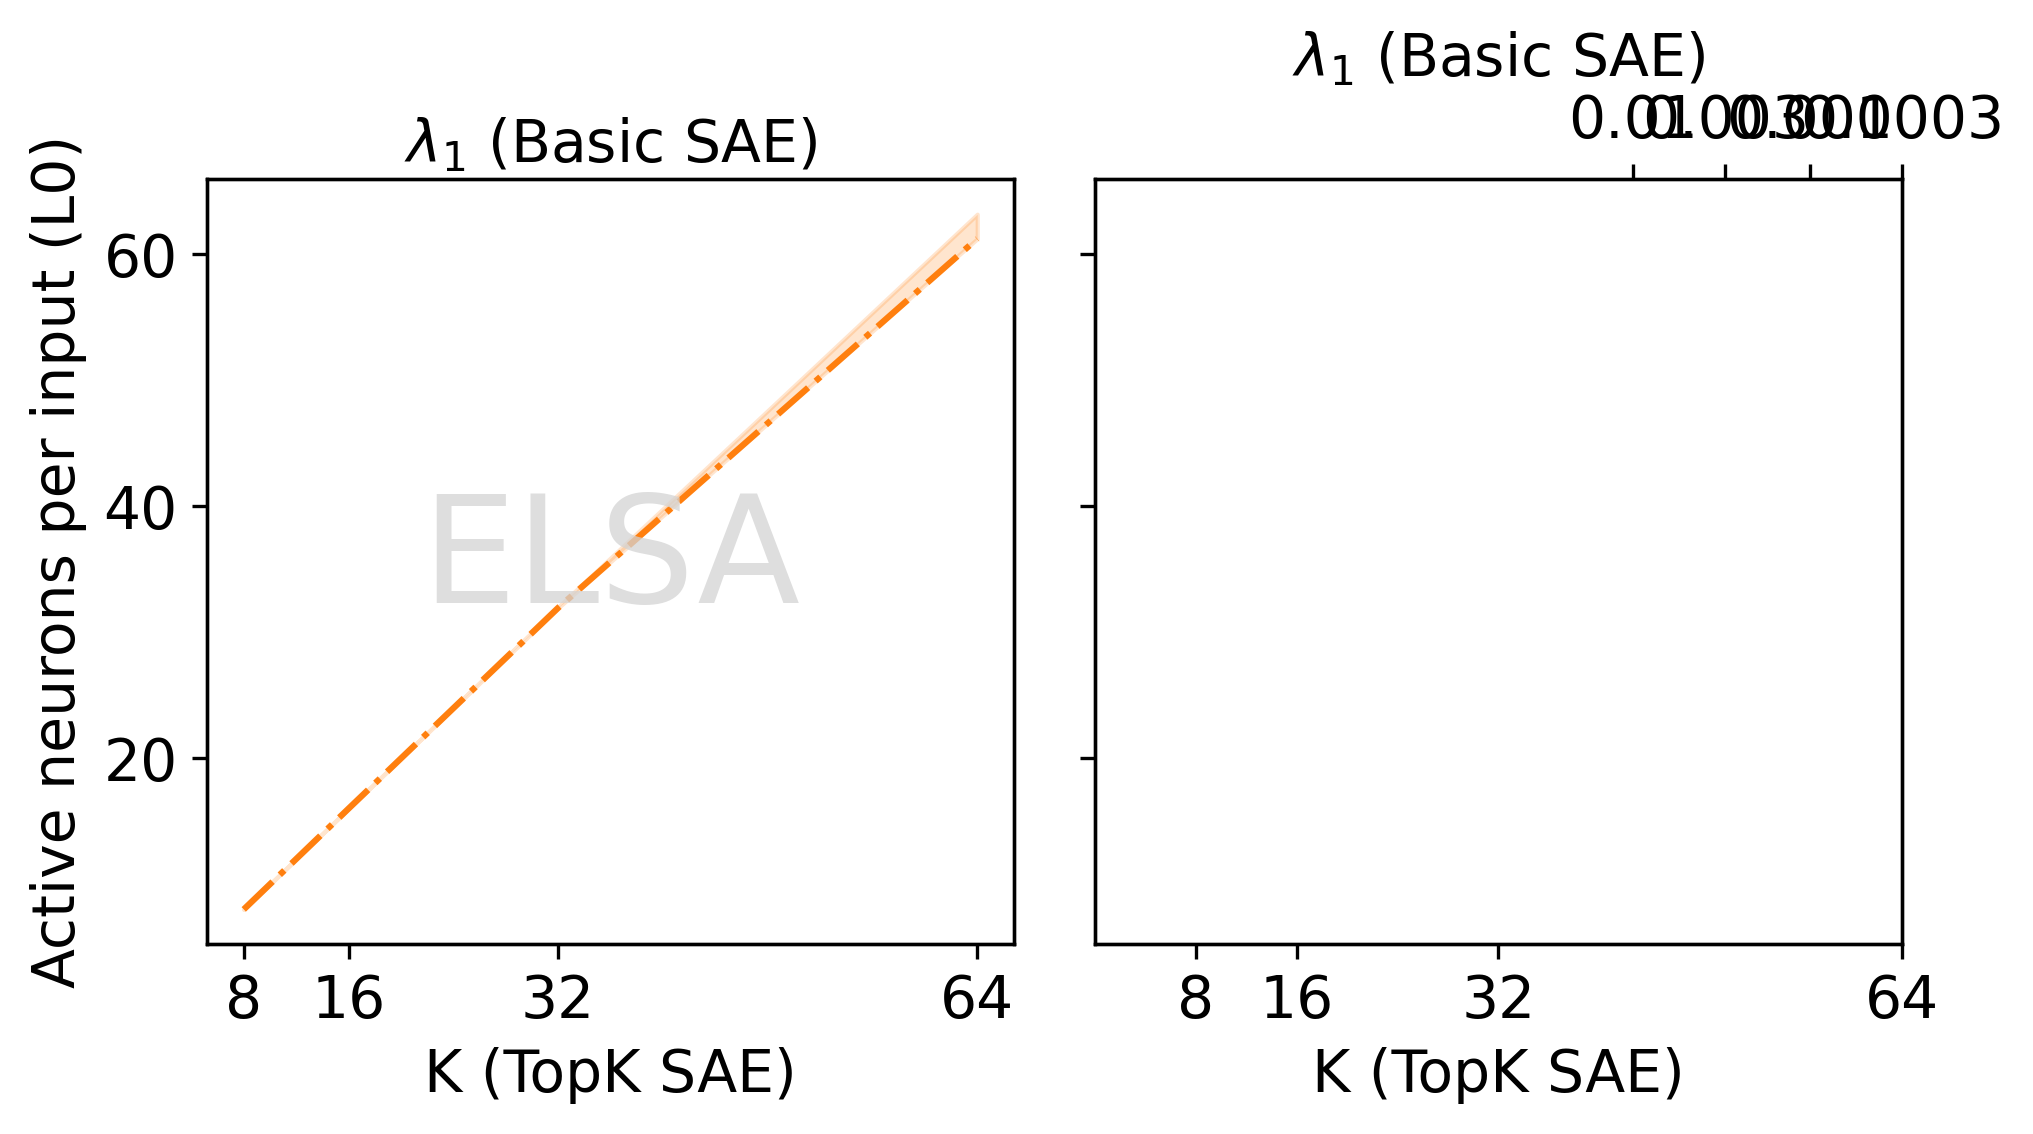

In [43]:
# hot fix
from pathlib import Path
Path("figures").mkdir(parents=True, exist_ok=True)
# -------

fig, (ax1a, ax2a) = plt.subplots(1, 2, sharey=True, constrained_layout=True, figsize=(7, 4))

ax1b = ax1a.twiny()
ax2b = ax2a.twiny()

metric = "l0 mean"

for cf_model, axa, axb in [("ELSA", ax1a, ax1b)]:
    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") != "BasicSAE"),
        x="k",
        y=metric,
        estimator="min",
        errorbar=lambda x: (x.min(), x.max()),
        palette=sns.color_palette()[1:],
        hue="model_class",
        linestyle="-.",
        markers=True,
        ax=axa,
        legend=False,
    )

    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") == "BasicSAE"),
        x="l1_coef",
        y=metric,
        color=sns.color_palette()[0],
        estimator="min",
        errorbar=lambda x: (x.min(), x.max()),
        linestyle="-.",
        markers=True,
        ax=axb,
        legend=False,
    )

    axa.text(0.5, 0.5, f"{cf_model}", transform=axa.transAxes, fontsize=36, color="lightgrey", alpha=0.75, ha="center", va="center")

ax1a.set_xticks([8, 16, 32, 64])
ax1a.set_xlabel("K (TopK SAE)")
ax1a.set_ylabel("Active neurons per input (L0)")
ax1b.set_xscale("log")
ax1b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax1b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax1b.invert_xaxis()
ax1b.minorticks_off()
ax1b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

ax2a.set_xticks([8, 16, 32, 64])
ax2a.set_xlabel("K (TopK SAE)")
ax2b.set_xscale("log")
ax2b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax2b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax2b.invert_xaxis()
ax2b.minorticks_off()
ax2b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

plt.tight_layout()
# plt.suptitle("Activation density", y=1.05, fontsize=16)
plt.savefig(f"figures/{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_big.png", bbox_inches="tight")
plt.show()

## Cosine similarity

/tmp/ipykernel_14733/1734876480.py:9: UserWarning: The palette list has more values (9) than needed (1), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_14733/1734876480.py:45: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/1734876480.py:45: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/1734876480.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


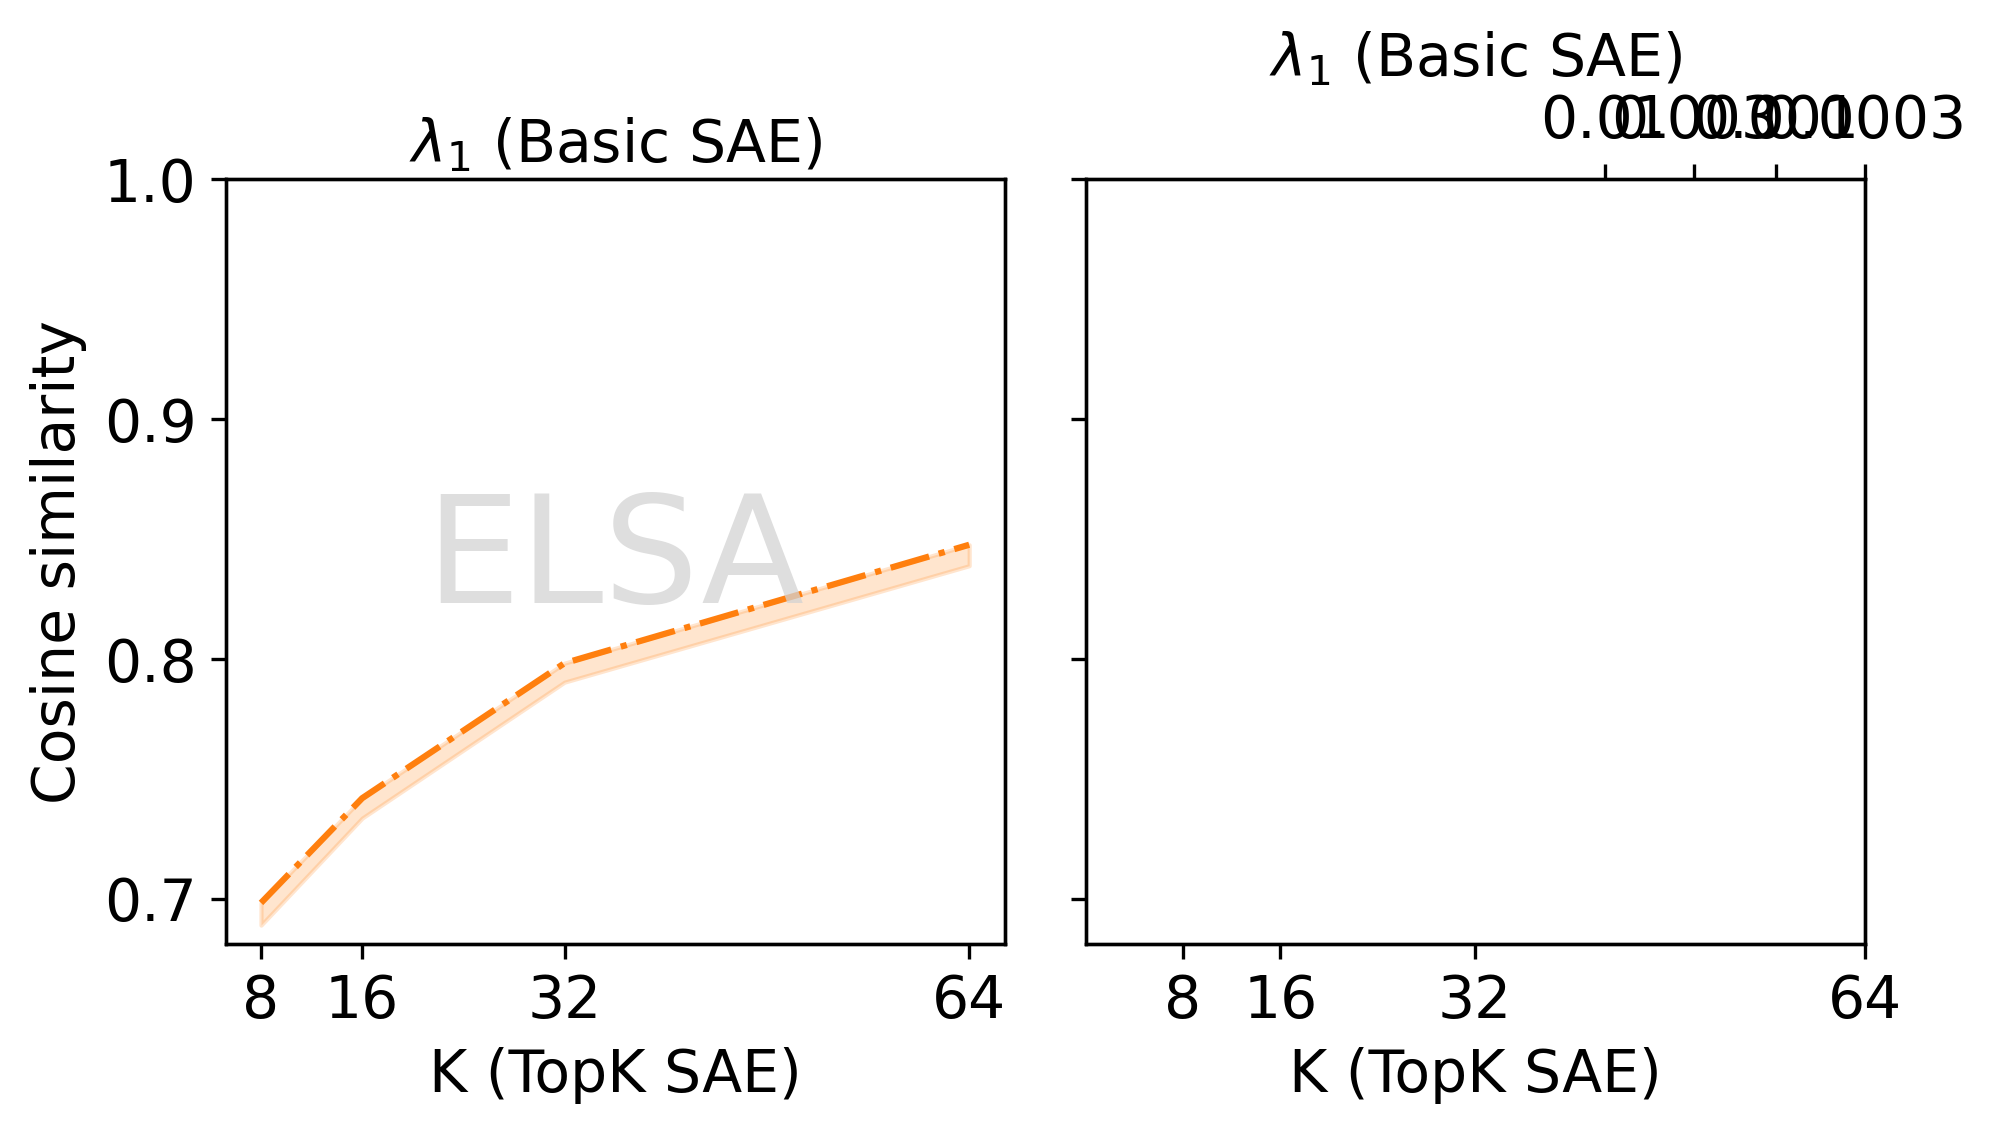

In [44]:
fig, (ax1a, ax2a) = plt.subplots(1, 2, sharey=True, constrained_layout=True, figsize=(7, 4))

ax1b = ax1a.twiny()
ax2b = ax2a.twiny()

metric = "cosine mean"

for cf_model, axa, axb in [("ELSA", ax1a, ax1b)]:
    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") != "BasicSAE"),
        x="k",
        y=metric,
        estimator="max",
        errorbar=lambda x: (x.min(), x.max()),
        palette=sns.color_palette()[1:],
        hue="model_class",
        linestyle="-.",
        markers=True,
        ax=axa,
        legend=False,
    )

    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") == "BasicSAE"),
        x="l1_coef",
        y=metric,
        color=sns.color_palette()[0],
        estimator="max",
        errorbar=lambda x: (x.min(), x.max()),
        linestyle="-.",
        markers=True,
        ax=axb,
        legend=False,
    )

    axa.text(0.5, 0.5, f"{cf_model}", transform=axa.transAxes, fontsize=36, color="lightgrey", alpha=0.75, ha="center", va="center")

ax1a.set_xticks([8, 16, 32, 64])
ax1a.set_xlabel("K (TopK SAE)")
ax1a.set_ylabel("Cosine similarity")
ax1a.set_ylim(ax1a.get_ylim()[0], 1)
ax1b.set_xscale("log")
ax1b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax1b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax1b.invert_xaxis()
ax1b.minorticks_off()
ax1b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

ax2a.set_xticks([8, 16, 32, 64])
ax2a.set_xlabel("K (TopK SAE)")
ax2b.set_xscale("log")
ax2b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax2b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax2b.invert_xaxis()
ax2b.minorticks_off()
ax2b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

plt.tight_layout()
# plt.suptitle("Embedding reconstruction accuracy", y=1.05, fontsize=16)
plt.savefig(f"figures/{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_big.png", bbox_inches="tight")
plt.show()

## Relative Recall

/tmp/ipykernel_14733/4280980956.py:9: UserWarning: The palette list has more values (9) than needed (1), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_14733/4280980956.py:46: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/4280980956.py:46: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/4280980956.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


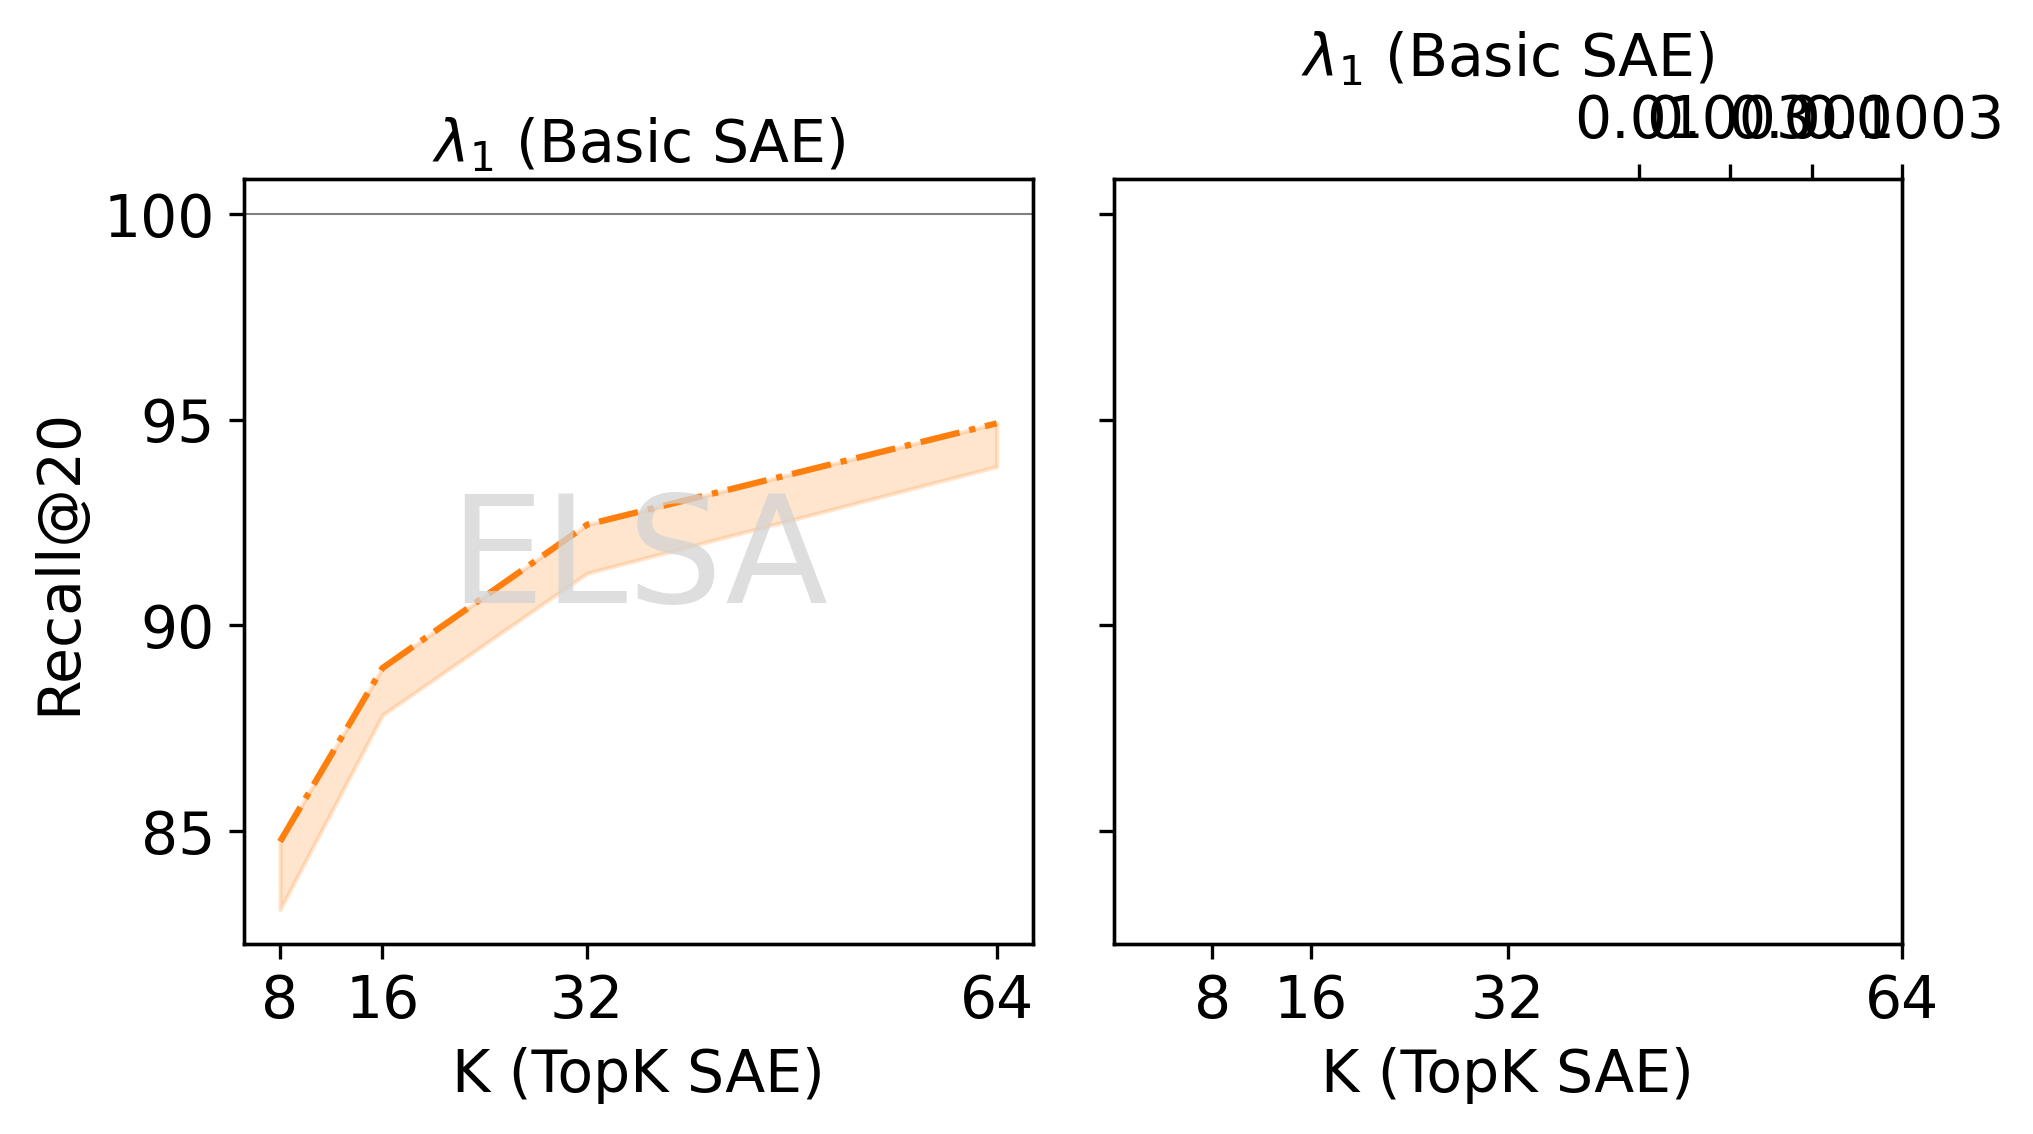

In [45]:
fig, (ax1a, ax2a) = plt.subplots(1, 2, sharey=True, constrained_layout=True, figsize=(7, 4))

ax1b = ax1a.twiny()
ax2b = ax2a.twiny()

metric = "relative recall"

for cf_model, axa, axb in [("ELSA", ax1a, ax1b)]:
    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") != "BasicSAE"),
        x="k",
        y=metric,
        estimator="max",
        errorbar=lambda x: (x.min(), x.max()),
        palette=sns.color_palette()[1:],
        hue="model_class",
        linestyle="-.",
        markers=True,
        ax=axa,
        legend=False,
    )

    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") == "BasicSAE"),
        x="l1_coef",
        y=metric,
        color=sns.color_palette()[0],
        estimator="max",
        errorbar=lambda x: (x.min(), x.max()),
        linestyle="-.",
        markers=True,
        ax=axb,
        legend=False,
    )

    axa.text(0.5, 0.5, f"{cf_model}", transform=axa.transAxes, fontsize=36, color="lightgrey", alpha=0.75, ha="center", va="center")

    axa.axhline(y=100, color="grey", linewidth=0.5)

ax1a.set_xticks([8, 16, 32, 64])
ax1a.set_xlabel("K (TopK SAE)")
ax1a.set_ylabel("Recall@20")
ax1b.set_xscale("log")
ax1b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax1b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax1b.invert_xaxis()
ax1b.minorticks_off()
ax1b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

ax2a.set_xticks([8, 16, 32, 64])
ax2a.set_xlabel("K (TopK SAE)")
ax2b.set_xscale("log")
ax2b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax2b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax2b.invert_xaxis()
ax2b.minorticks_off()
ax2b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

plt.tight_layout()
# plt.suptitle("Recovered downstream performance %", y=1.03, fontsize=16)
plt.savefig(f"figures/{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_big.png", bbox_inches="tight")
plt.show()

## Relative nDCG

/tmp/ipykernel_14733/193338610.py:9: UserWarning: The palette list has more values (9) than needed (1), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_14733/193338610.py:46: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/193338610.py:46: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1b.invert_xaxis()
/tmp/ipykernel_14733/193338610.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


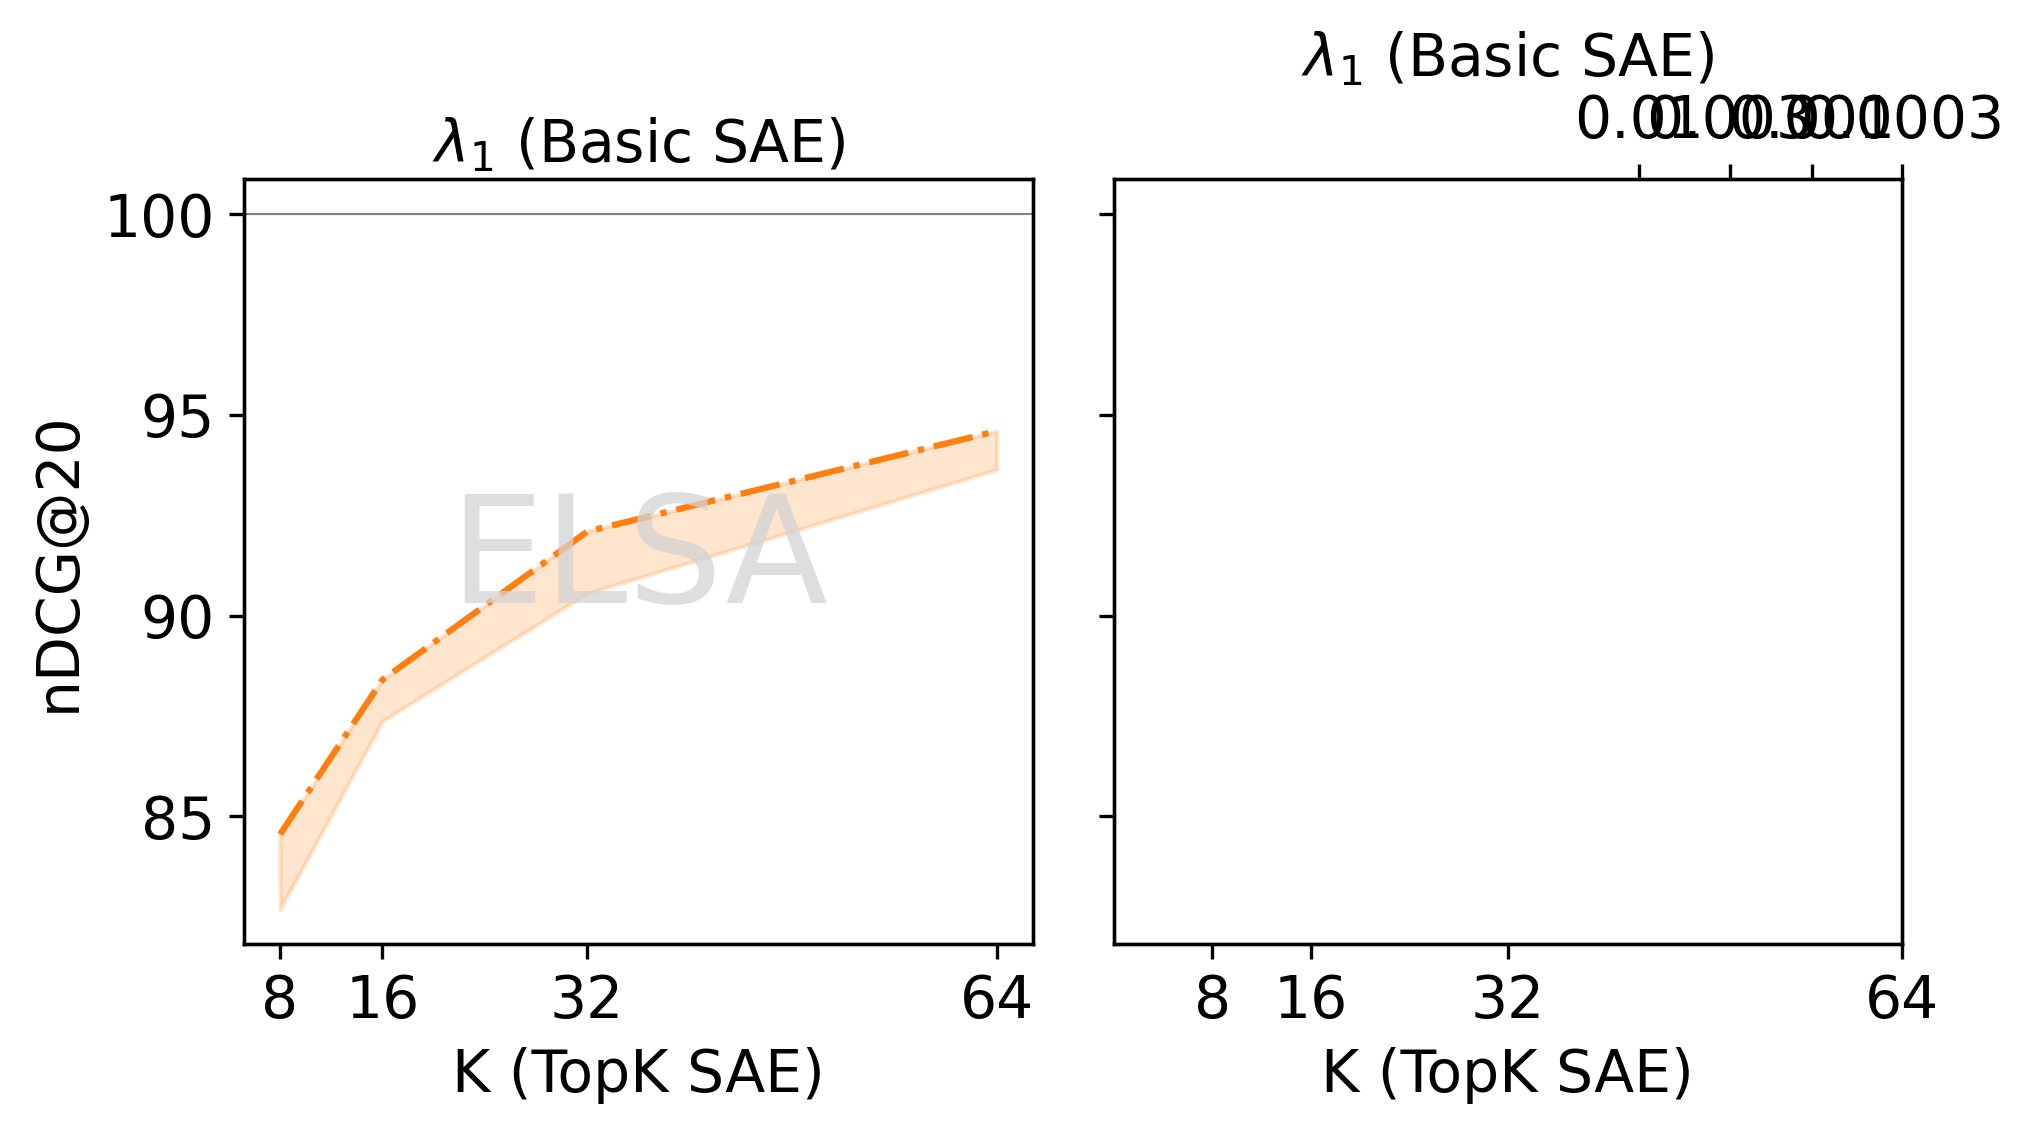

In [46]:
fig, (ax1a, ax2a) = plt.subplots(1, 2, sharey=True, constrained_layout=True, figsize=(7, 4))

ax1b = ax1a.twiny()
ax2b = ax2a.twiny()

metric = "relative ndcg"

for cf_model, axa, axb in [("ELSA", ax1a, ax1b)]:
    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") != "BasicSAE"),
        x="k",
        y=metric,
        estimator="max",
        errorbar=lambda x: (x.min(), x.max()),
        palette=sns.color_palette()[1:],
        hue="model_class",
        linestyle="-.",
        markers=True,
        ax=axa,
        legend=False,
    )

    sns.lineplot(
        data=_df.filter(pl.col("cf_model") == cf_model).filter(pl.col("model_class") == "BasicSAE"),
        x="l1_coef",
        y=metric,
        color=sns.color_palette()[0],
        estimator="max",
        errorbar=lambda x: (x.min(), x.max()),
        linestyle="-.",
        markers=True,
        ax=axb,
        legend=False,
    )

    axa.text(0.5, 0.5, f"{cf_model}", transform=axa.transAxes, fontsize=36, color="lightgrey", alpha=0.75, ha="center", va="center")

    axa.axhline(y=100, color="grey", linewidth=0.5)

ax1a.set_xticks([8, 16, 32, 64])
ax1a.set_xlabel("K (TopK SAE)")
ax1a.set_ylabel("nDCG@20")
ax1b.set_xscale("log")
ax1b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax1b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax1b.invert_xaxis()
ax1b.minorticks_off()
ax1b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

ax2a.set_xticks([8, 16, 32, 64])
ax2a.set_xlabel("K (TopK SAE)")
ax2b.set_xscale("log")
ax2b.set_xticks([0.0003, 0.001, 0.003, 0.01])
ax2b.set_xticklabels([0.0003, 0.001, 0.003, 0.01])
ax2b.invert_xaxis()
ax2b.minorticks_off()
ax2b.set_xlabel(r"$\lambda_1$ (Basic SAE)")

plt.tight_layout()
# plt.suptitle("Recovered downstream performance %", y=1.03, fontsize=16)
plt.savefig(f"figures/{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_big.png", bbox_inches="tight")
plt.show()

In [47]:
result_dataframes[dataset][split]["sae models"].filter(pl.col("input_dim") == 1024).filter(pl.col("model_class") == "TopKSAE (Cosine)").filter(
    pl.col("k") == 32
).sort("recall mean")

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,f64
"""TopKSAE-2048-088b6417.json""","""ml-32m-filtered""","""ELSA-1024-66e73686.ckpt""","""sae""","""TopKSAE (Cosine)""",2048,"""Cosine""",0.0003,32,60,12,1024,0.0003,0.9,0.99,42,0.818567,0.00158,32.0,0.0,0,0.343866,0.002506,-0.019491,0.001087,0.350702,0.002589,-0.020694,0.000896,1024,2,"""ELSA""",2.0
"""TopKSAE-4096-86effed3.json""","""ml-32m-filtered""","""ELSA-1024-66e73686.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,32,120,20,1024,0.0003,0.9,0.99,42,0.826737,0.001612,31.999838,0.000161,28,0.343953,0.002518,-0.01893,0.001076,0.350407,0.002602,-0.019302,0.000876,1024,4,"""ELSA""",2.0
"""TopKSAE-4096-4a9737ef.json""","""ml-32m-filtered""","""ELSA-1024-66e73686.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,32,60,12,1024,0.0003,0.9,0.99,42,0.82158,0.001549,32.0,0.0,27,0.34587,0.002514,-0.017487,0.001052,0.352416,0.002598,-0.018981,0.000873,1024,4,"""ELSA""",2.0


In [37]:
dataset = DATASETS[0]
split = "val"

sae_df = result_dataframes[dataset][split]["sae models"].with_columns(
    (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
    (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
)

# Keep only TopKSAE rows for current case clarity.
sae_df = sae_df.filter(pl.col("model_class").str.starts_with("TopKSAE"))

cf_baseline_df = result_dataframes[dataset][split]["cf models"].filter(pl.col("model_class") == "ELSA")

print("SAE rows:", sae_df.height)
print("CF rows:", cf_baseline_df.height)
sae_df.select(["embedding_dim", "k", "input_dim", "cf_model_size", "l0 mean", "recall mean", "ndcg mean", "ndcg degradation mean"]).sort(["input_dim", "embedding_dim", "k"])

SAE rows: 17
CF rows: 5


embedding_dim,k,input_dim,cf_model_size,l0 mean,recall mean,ndcg mean,ndcg degradation mean
i64,i64,i64,f64,f64,f64,f64,f64
2048,16,1024,2.0,16.0,0.33309,0.339198,-0.033236
2048,32,1024,2.0,32.0,0.343866,0.350702,-0.020694
4096,16,1024,2.0,16.0,0.334676,0.341967,-0.02943
4096,32,1024,2.0,32.0,0.34587,0.352416,-0.018981
4096,32,1024,2.0,31.999838,0.343953,0.350407,-0.019302
…,…,…,…,…,…,…,…
8192,64,2048,4.0,61.225254,0.35097,0.358844,-0.022868
16384,8,2048,4.0,8.0,0.316776,0.324027,-0.059203
16384,16,2048,4.0,16.0,0.330866,0.337404,-0.044267


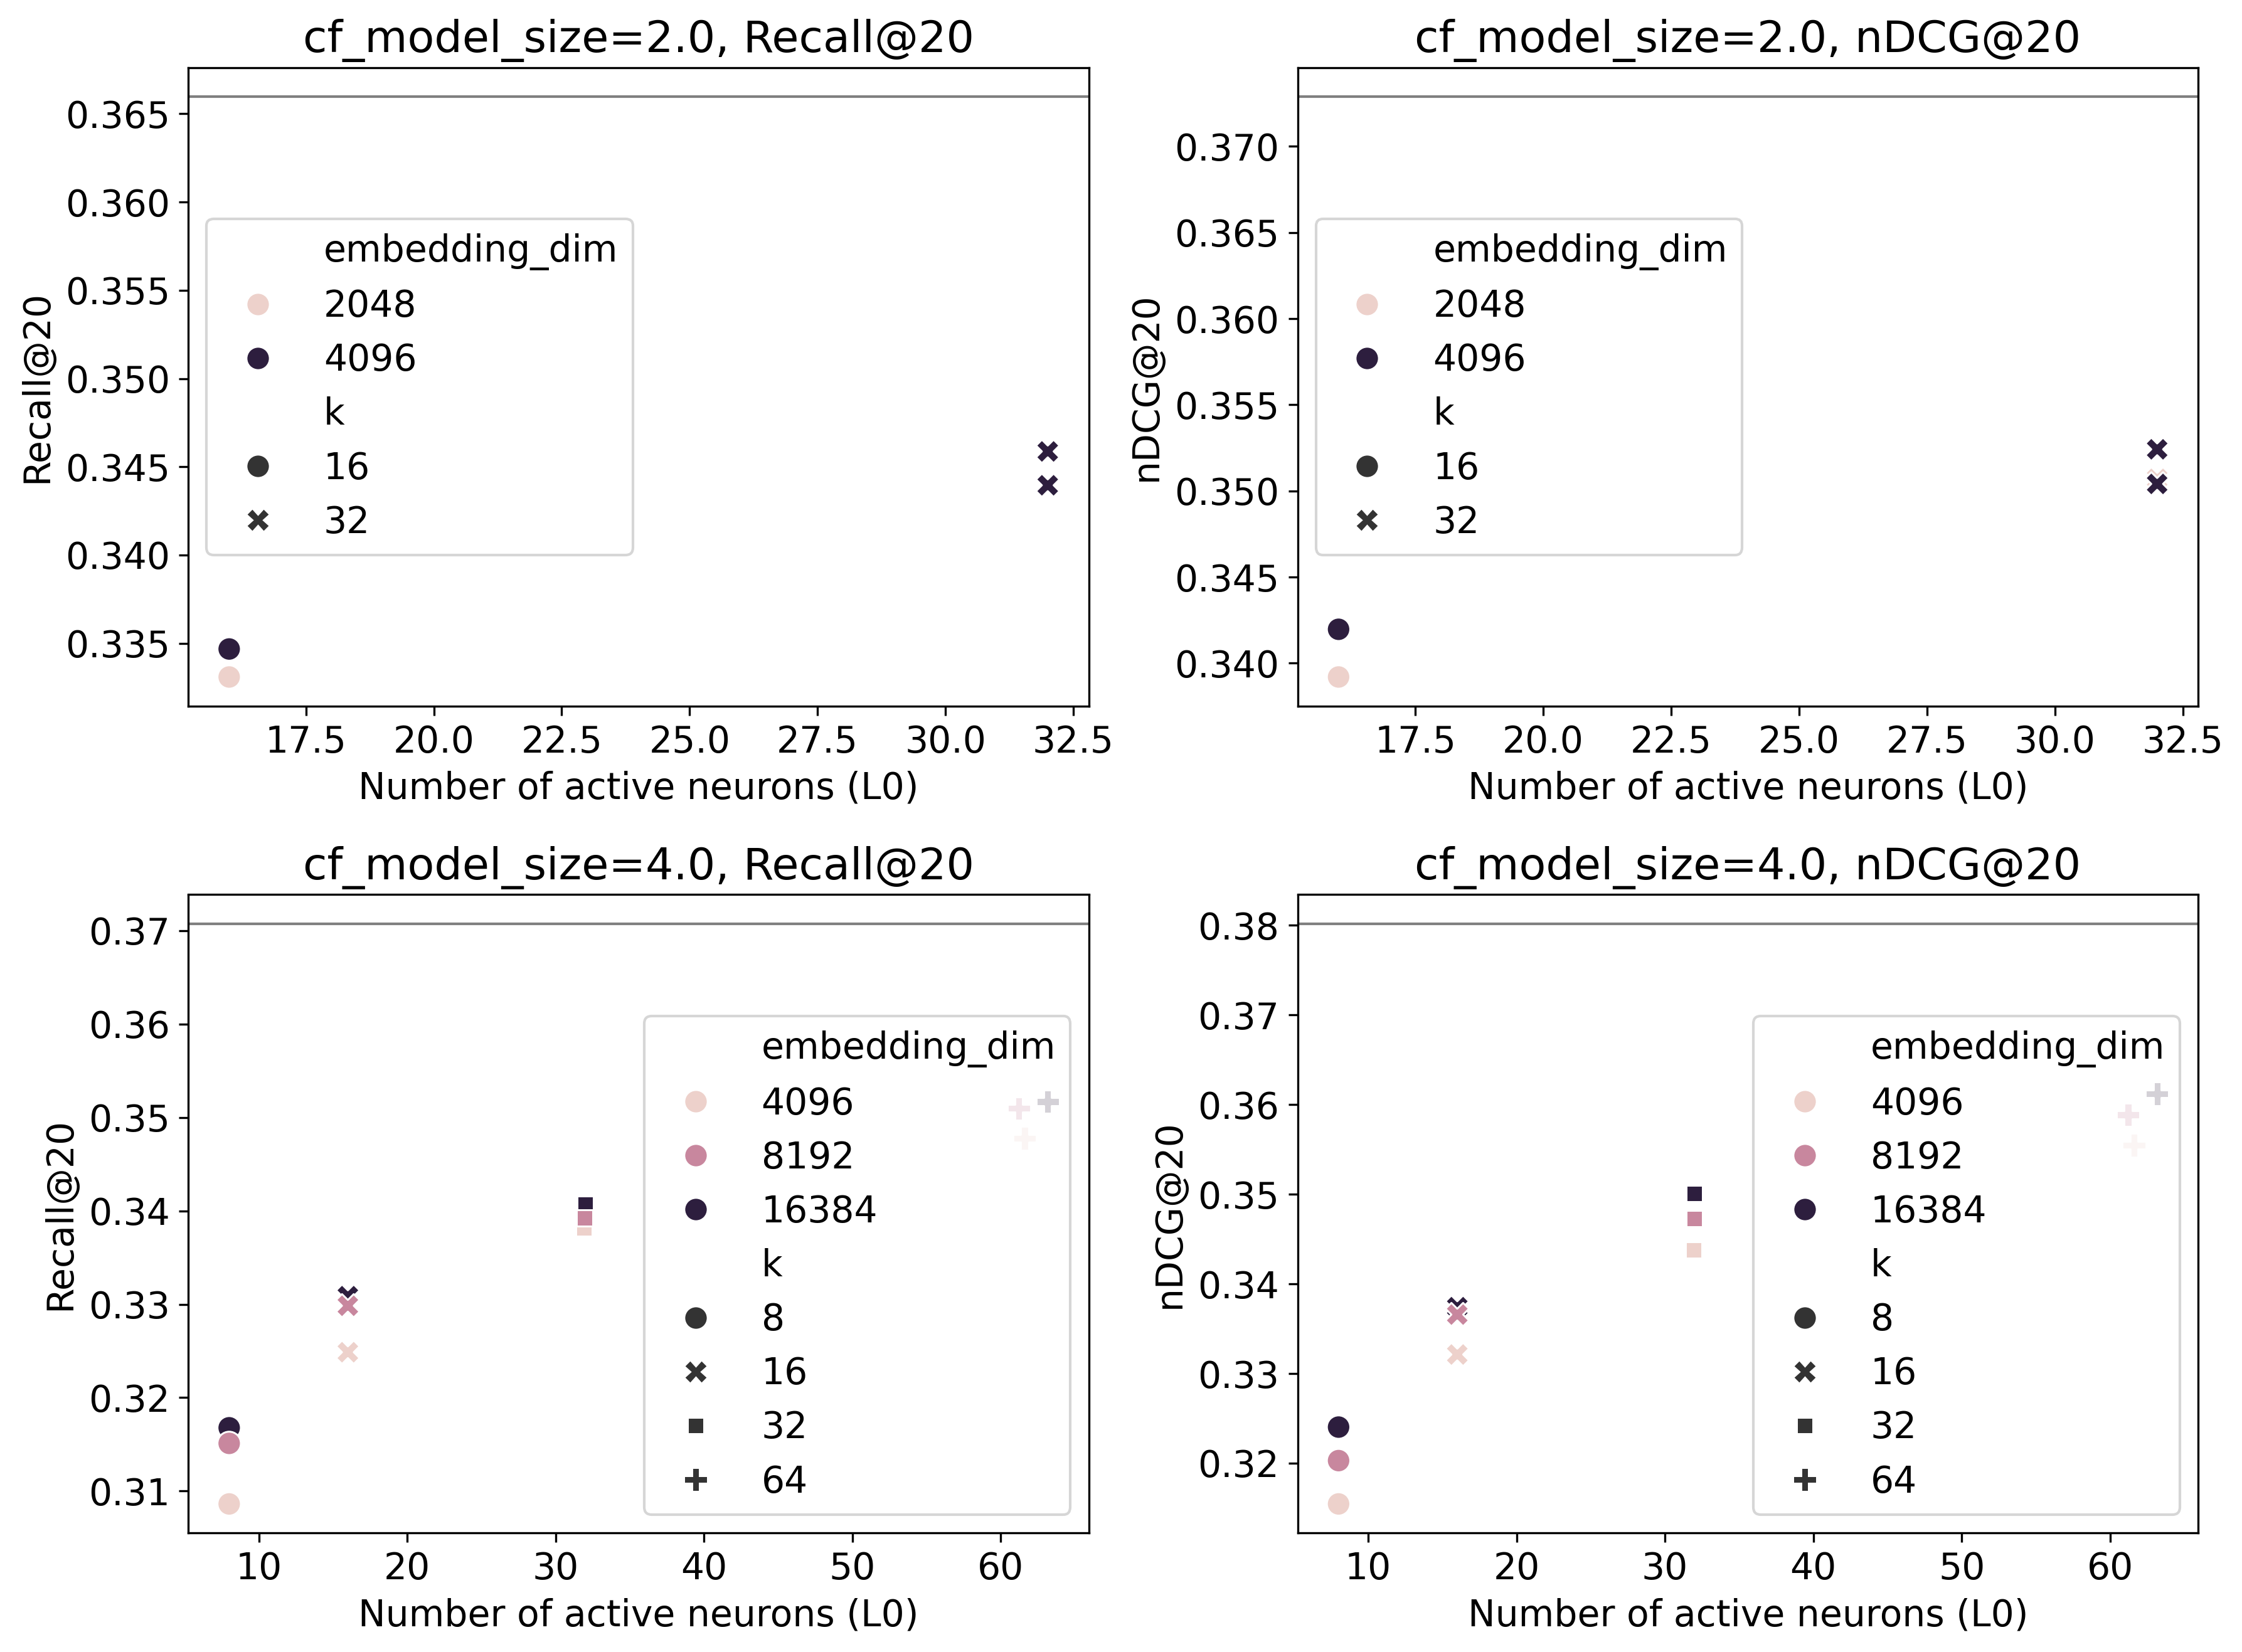

In [38]:
# All TopKSAE points, faceted by cf_model_size
cf_sizes = sorted(sae_df.select("cf_model_size").unique().to_series().to_list())
metrics = [("recall mean", "Recall@20"), ("ndcg mean", "nDCG@20")]

fig, axes = plt.subplots(len(cf_sizes), len(metrics), figsize=(6 * len(metrics), 4.5 * len(cf_sizes)), squeeze=False)

for i, cf_size in enumerate(cf_sizes):
    sub = sae_df.filter(pl.col("cf_model_size") == cf_size)
    baseline_row = cf_baseline_df.filter(pl.col("embedding_dim") == int(cf_size * 512))

    for j, (metric_col, metric_label) in enumerate(metrics):
        ax = axes[i, j]
        sns.scatterplot(
            data=sub,
            x="l0 mean",
            y=metric_col,
            hue="embedding_dim",
            style="k",
            ax=ax,
            s=80,
        )
        if baseline_row.height > 0:
            ax.axhline(float(baseline_row[metric_col][0]), color="grey", linewidth=1)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel(metric_label)
        ax.set_title(f"cf_model_size={cf_size}, {metric_label}")

plt.tight_layout()
plt.show()

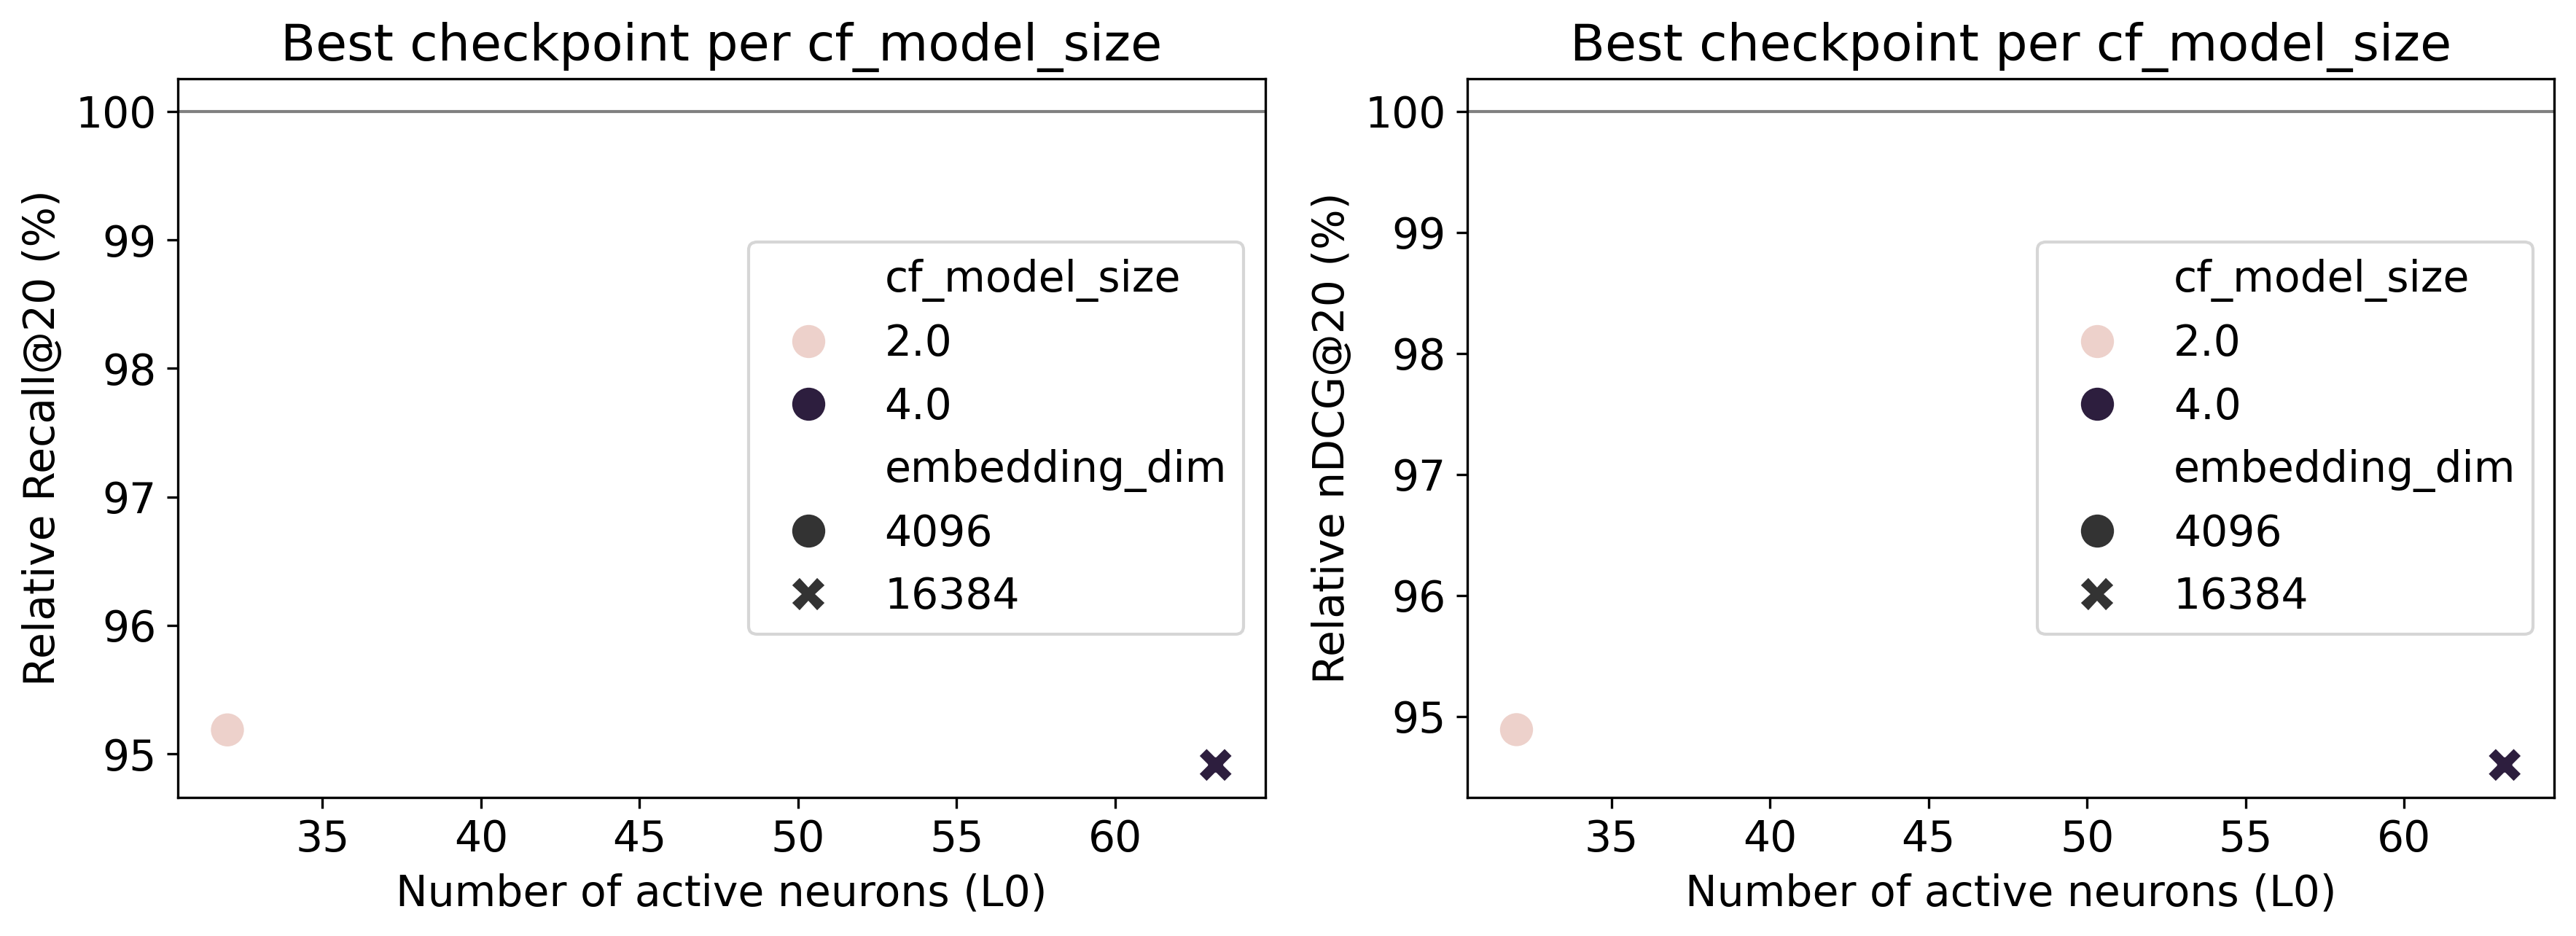

cf_model_size,checkpoint,embedding_dim,k,l0 mean,recall mean,ndcg mean,recall degradation mean,ndcg degradation mean
f64,str,i64,i64,f64,f64,f64,f64,f64
2.0,"""TopKSAE-4096-4a9737ef.json""",4096,32,32.0,0.34587,0.352416,-0.017487,-0.018981
4.0,"""TopKSAE-16384-a4f931b4.json""",16384,64,63.172775,0.351676,0.361193,-0.018842,-0.020628


In [39]:
# One checkpoint per cf_model_size (best by ndcg degradation mean, i.e. closest to 0)
best_per_cf = (
    sae_df
    .sort(["cf_model_size", "ndcg degradation mean"], descending=[False, True])
    .group_by("cf_model_size")
    .first()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), squeeze=False)
for j, (metric_col, metric_label) in enumerate([("relative recall", "Relative Recall@20 (%)"), ("relative ndcg", "Relative nDCG@20 (%)")]):
    ax = axes[0, j]
    sns.scatterplot(
        data=best_per_cf,
        x="l0 mean",
        y=metric_col,
        hue="cf_model_size",
        style="embedding_dim",
        ax=ax,
        s=140,
    )
    ax.axhline(100.0, color="grey", linewidth=1)
    ax.set_xlabel("Number of active neurons (L0)")
    ax.set_ylabel(metric_label)
    ax.set_title("Best checkpoint per cf_model_size")

plt.tight_layout()
plt.show()

best_per_cf.select([
    "cf_model_size", "checkpoint", "embedding_dim", "k", "l0 mean", "recall mean", "ndcg mean", "recall degradation mean", "ndcg degradation mean"
]).sort("cf_model_size")

In [40]:
# Primary criterion: max ndcg degradation mean (least negative); tie-breaker: max recall degradation mean.
final_best = (
    sae_df
    .sort(["ndcg degradation mean", "recall degradation mean"], descending=[True, True])
    .head(1)
)

print("Best checkpoint for current case:")
final_best.select([
    "checkpoint",
    "pretrained_model_checkpoint",
    "input_dim",
    "embedding_dim",
    "k",
    "l0 mean",
    "cosine mean",
    "dead neurons",
    "recall mean",
    "recall degradation mean",
    "ndcg mean",
    "ndcg degradation mean",
])

Best checkpoint for current case:


checkpoint,pretrained_model_checkpoint,input_dim,embedding_dim,k,l0 mean,cosine mean,dead neurons,recall mean,recall degradation mean,ndcg mean,ndcg degradation mean
str,str,i64,i64,i64,f64,f64,i64,f64,f64,f64,f64
"""TopKSAE-4096-4a9737ef.json""","""ELSA-1024-66e73686.ckpt""",1024,4096,32,32.0,0.82158,27,0.34587,-0.017487,0.352416,-0.018981
